# LSTM - PRE-TRAINING IKLIM (ERA5) Interval 1 Jam


## Tahap 1: Inisialisasi dan Impor Library

Sel ini memuat semua pustaka (library) yang dibutuhkan oleh model, termasuk manipulasi data (Pandas/Numpy), pemodelan (XGBoost/Tensorflow), metrik evaluasi (Scikit-Learn), serta mematikan peringatan (*warnings*) agar *output* tetap bersih.

In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import shap
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression  # Untuk Platt Scaling [AUDIT FIX]
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix,
    brier_score_loss, mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['lines.linewidth'] = 2.0

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...")


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger, ModelCheckpoint  # [AUDIT FIX]


2026-07-14 07:08:33,743 - INFO - Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...
2026-07-14 07:08:35.311296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784012915.494531      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784012915.549525      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784012915.991180      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784012915.991216      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than onc

## Tahap 2: Konfigurasi Global & Konstanta

Sel ini mendefinisikan seluruh variabel kontrol untuk *pipeline*. Anda bisa mengganti mode berjalannya notebook (`RUN_MODE`) menjadi mode cepat (*fast-test*) atau mode penuh (*pipeline_test*), serta menentukan jumlah *trials* Optuna.

In [2]:
# Sel 2: Konfigurasi Global
# File ini mendefinisikan konstanta fisik, rentang waktu pre-training, dan parameter HPO LSTM.
# Seluruh pengaturan bias correction telah dinonaktifkan/dihapus agar model fokus pada machine learning murni.
RUN_MODE = "FULL_TRAIN"  # "FULL_TRAIN" untuk latihan penuh, "PIPELINE_TEST" untuk uji coba cepat
SEED = 281225

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS = 5
    EPOCHS = 2
else:
    OPTUNA_TRIALS = 30  # Jumlah trial optimasi hyperparameter dengan Optuna
    EPOCHS = 50  # Jumlah epoch pelatihan LSTM

# Panjang urutan waktu (sequence) ke belakang untuk LSTM
LOOKBACK = 24

# Direktori output model dan visualisasi
from pathlib import Path
BASE_OUTPUT_DIR = Path('outputs_lstm')

# Batas ambang curah hujan untuk klasifikasi hujan/tidak hujan (mm/jam)
RAIN_THRESHOLD = 0.2

# Rentang tanggal pre-training menggunakan data satelit & ERA5
PRETRAIN__TRAIN_START = '2005-01-01'
PRETRAIN__TRAIN_END   = '2020-12-31'
PRETRAIN__VAL_START   = '2021-01-01'
PRETRAIN__VAL_END     = '2023-12-31'
PRETRAIN__TEST_START  = '2024-01-01'
PRETRAIN__TEST_END    = '2025-12-31'

# Batas tanggal fine-tuning menggunakan data aktual stasiun AWS bumi
FINETUNE_TRAIN_START = '2025-01-01'
FINETUNE_TRAIN_END   = '2026-01-15'
FINETUNE_VAL_START   = '2026-01-16'
FINETUNE_VAL_END     = '2026-04-05'
FINETUNE_TEST_START  = '2026-04-06'
FINETUNE_TEST_END    = '2026-05-31'

# Pemetaan fitur dari kolom mentah dataset ERA5 ke nama variabel meteorologi standar
ERA5_FEATURES_MAPPING = {
    'temperature_era5': 'temperature',
    'humidity_era5': 'humidity',
    'dewpoint_era5': 'dewpoint',
    'rain_mm': 'rainrate',
    'sealevel_pressure_era5': 'pressure',
    'u10_era5': 'era5_u_wind',
    'v10_era5': 'era5_v_wind',
    'cloud_cover_era5': 'era5_cloud_cover',
    'cape_era5': 'era5_cape',
    'total_column_water_vapour_era5': 'era5_tcwv',
    'moisture_divergence_era5': 'era5_moisture_div',
    'direct_radiation_era5': 'era5_direct_rad',
    'sunshine_duration_era5': 'era5_sunshine'
}


## Tahap 3: Mesin Evaluasi Terpadu (*ModelEvaluator*)

Ini adalah mesin (*engine*) utama untuk melakukan pelaporan hasil model. Kelas ini bertanggung jawab menghitung semua metrik meteorologi (CSI, POD, FAR), metrik klasifikasi (ROC-AUC), metrik regresi (RMSE), serta menyimpan seluruh grafik evaluasi dan kurva kalibrasi secara otomatis ke folder `outputs_lstm/`.

In [3]:
# Sel 3: Mesin Evaluasi Terpadu (Unified Evaluation Engine)
def fit_best_calibrator(y_val, val_probs):
    from sklearn.linear_model import LogisticRegression
    from sklearn.isotonic import IsotonicRegression
    from sklearn.metrics import brier_score_loss
    
    # Platt
    platt = LogisticRegression()
    try:
        platt.fit(val_probs.reshape(-1, 1), y_val)
        platt_probs = platt.predict_proba(val_probs.reshape(-1, 1))[:, 1]
        platt_brier = brier_score_loss(y_val, platt_probs)
    except:
        platt = None
        platt_brier = 999
        
    # Isotonic
    iso = IsotonicRegression(out_of_bounds='clip')
    try:
        iso.fit(val_probs, y_val)
        iso_probs = iso.predict(val_probs)
        iso_brier = brier_score_loss(y_val, iso_probs)
    except:
        iso = None
        iso_brier = 999
        
    raw_brier = brier_score_loss(y_val, val_probs)
    
    logger.info(f"[Calibrator Selection] Brier scores - Raw: {raw_brier:.4f}, Platt: {platt_brier:.4f}, Isotonic: {iso_brier:.4f}")
    
    if iso_brier <= platt_brier and iso_brier < raw_brier:
        logger.info("[Calibrator Selection] Selected Isotonic Calibrator")
        return iso, "Isotonic"
    elif platt_brier < iso_brier and platt_brier < raw_brier:
        logger.info("[Calibrator Selection] Selected Platt Calibrator")
        return platt, "Platt"
    else:
        logger.info("[Calibrator Selection] Selected Raw Calibrator (No calibration applied)")
        return None, "Raw"

def apply_calibrator(calibrator, calibrator_type, probs):
    if calibrator_type == "Isotonic":
        return calibrator.predict(probs)
    elif calibrator_type == "Platt":
        return calibrator.predict_proba(probs.reshape(-1, 1))[:, 1]
    else:
        return probs.copy()

def compute_ece_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    n = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        err  = abs(acc - conf)
        ece += (mask.sum() / n) * err
        mce  = max(mce, err)
    return float(ece), float(mce)

class ModelEvaluator:
    def __init__(self):
        self.base_dir = BASE_OUTPUT_DIR
        self.dirs = {
            'models': self.base_dir / 'models',
            'models_klasifikasi': self.base_dir / 'models' / 'classifier',
            'models_estimasi': self.base_dir / 'models' / 'regressor',
            'models_kalibrasi': self.base_dir / 'models' / 'calibration',
            'models_clf': self.base_dir / 'models' / 'classifier',
            'models_reg': self.base_dir / 'models' / 'regressor',
            'models_cal': self.base_dir / 'models' / 'calibration',
            'metrics': self.base_dir / 'metrics',
            'reports': self.base_dir / 'reports',
            'plots': self.base_dir / 'plots',
        }
        
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
    def calc_meteorological_metrics(self, y_true, y_pred):
        hits = np.sum((y_pred == 1) & (y_true == 1))
        misses = np.sum((y_pred == 0) & (y_true == 1))
        false_alarms = np.sum((y_pred == 1) & (y_true == 0))
        correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
        
        total = len(y_true)
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        
        csi = hits / (hits + misses + false_alarms + 1e-9)
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
        
        return {'CSI': float(csi), 'POD': float(pod), 'FAR': float(far), 'ETS': float(ets), 'HSS': float(hss)}

    def calc_hydrological_metrics(self, y_true, y_pred):
        if len(y_true) < 2: return {'NSE': 0.0, 'KGE': 0.0, 'Correlation': 0.0}
        mean_obs, mean_sim = np.mean(y_true), np.mean(y_pred)
        std_obs, std_sim = np.std(y_true), np.std(y_pred)
        
        numerator = np.sum((y_true - y_pred)**2)
        denominator = np.sum((y_true - mean_obs)**2)
        nse = 1 - (numerator / (denominator + 1e-9))
        
        if std_obs > 0 and std_sim > 0:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            beta = mean_sim / (mean_obs + 1e-9)
            gamma = (std_sim / mean_sim) / (std_obs / mean_obs + 1e-9) if mean_sim > 0 else 0
            kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)
        else:
            r, kge = 0.0, 0.0
            
        return {'NSE': float(nse), 'KGE': float(kge), 'Correlation': float(r)}

    def evaluate_classification(self, y_true, y_prob_uncal, y_prob_cal, y_pred):
        logger.info("Menghitung metrik klasifikasi...")
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob_cal)
        
        brier_uncal = brier_score_loss(y_true, y_prob_uncal)
        brier_cal = brier_score_loss(y_true, y_prob_cal)
        
        precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob_cal)
        pr_auc = auc(recall_arr, precision_arr)
        
        metrics = {
            'Accuracy': float(acc), 
            'Precision': float(prec), 
            'Recall': float(rec), 
            'F1 Score': float(f1), 
            'ROC-AUC': float(roc_auc), 
            'PR-AUC': float(pr_auc), 
            'Brier Score (Uncalibrated)': float(brier_uncal),
            'Brier Score (Calibrated)': float(brier_cal)
        }
        
        with open(self.dirs['metrics'] / 'classification_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
            
        meteo_metrics = self.calc_meteorological_metrics(y_true, y_pred)
        with open(self.dirs['metrics'] / 'meteorological_metrics.json', 'w') as f:
            json.dump(meteo_metrics, f, indent=4)
            
        
        self.plot_calibration_curve(y_true, y_prob_uncal, y_prob_cal)
        self.plot_reliability_diagram(y_true, y_prob_uncal, y_prob_cal)
        self.plot_probability_distribution(y_prob_cal)
        self.plot_roc_curve(y_true, y_prob_cal)
        self.plot_precision_recall_curve(y_true, y_prob_cal)
        self.plot_threshold_analysis(y_true, y_prob_cal)
        
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics, meteo_metrics

    def evaluate_regression(self, y_true, y_pred):
        logger.info("Menghitung metrik regresi...")
        if len(y_true) == 0: return {}
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        hydro = self.calc_hydrological_metrics(y_true, y_pred)
        
        metrics = {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'Bias': float(bias)}
        metrics.update(hydro)
        
        with open(self.dirs['metrics'] / 'regression_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics

    # --- 01_probability plots ---
    def plot_reliability_diagram(self, y_true, y_prob_uncal, y_prob_cal):
        plt.figure(figsize=(10,8))
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Reliability Diagram')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'reliability_diagram.png', dpi=300)
        plt.show()

    def plot_probability_distribution(self, y_prob_cal):
        plt.figure(figsize=(10,8))
        sns.histplot(y_prob_cal, bins=20, kde=True, color='green', alpha=0.5)
        plt.title('Probability Distribution')
        plt.xlabel('Probabilitas Klasifikasi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'probability_distribution.png', dpi=300)
        plt.show()

    def plot_calibration_curve(self, y_true, y_prob_uncal, y_prob_cal=None):
        plt.figure(figsize=(10,8))
        prob_true, prob_pred = calibration_curve(y_true, y_prob_uncal, n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated Model', color='blue')
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated Model', color='green')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Calibration Curve (Uncalibrated vs Calibrated)')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Kejadian Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'calibration_curve.png', dpi=300)
        plt.show()

    # --- 02_classification plots ---
    def plot_confusion_matrix(self, y_true, y_pred, suffix=''):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix' + (' ' + suffix if suffix else ''))
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.tight_layout()
        filename = f'confusion_matrix_{suffix.strip().lower().replace(" ", "_")}.png' if suffix else 'confusion_matrix.png'
        plt.savefig(self.dirs['plots'] / filename, dpi=300)
        plt.show()
        
    def plot_roc_curve(self, y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(10,10))
        plt.plot(fpr, tpr, color='darkorange', lw=2)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'roc_curve.png', dpi=300)
        plt.show()

    def plot_precision_recall_curve(self, y_true, y_prob):
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(10,10))
        plt.plot(recall, precision, color='purple', lw=2)
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'precision_recall_curve.png', dpi=300)
        plt.show()

    def plot_threshold_analysis(self, y_true, y_prob):
        thresholds = np.linspace(0.1, 0.9, 50)
        f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        plt.figure(figsize=(10,6))
        plt.plot(thresholds, f1_scores, marker='x', color='blue')
        plt.title('Threshold Analysis (F1 Score)')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'threshold_analysis.png', dpi=300)
        plt.show()

    # --- 03_regression plots ---
    def plot_prediction_vs_observation(self, y_true, y_pred):
        if len(y_true) == 0: return
        plt.figure(figsize=(10,10))
        plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
        max_val = max(np.max(y_true), np.max(y_pred))
        plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        plt.title('Prediction vs Observation')
        plt.xlabel('Observasi (mm)')
        plt.ylabel('Prediksi (mm)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'prediction_vs_observation.png', dpi=300)
        plt.show()

    def plot_residual_distribution(self, residuals):
        plt.figure(figsize=(10,8))
        sns.histplot(residuals, kde=True, color='crimson')
        plt.title('Residual Distribution')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'residual_distribution.png', dpi=300)
        plt.show()
        
    def plot_qq_plot(self, residuals):
        plt.figure(figsize=(10,10))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title('QQ Plot of Residuals')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'qq_plot.png', dpi=300)
        plt.show()

    def plot_error_distribution(self, y_true, y_pred):
        abs_errors = np.abs(y_true - y_pred)
        plt.figure(figsize=(10,8))
        sns.boxplot(y=abs_errors, color='orange')
        plt.title('Error Distribution (Absolute)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'error_distribution.png', dpi=300)
        plt.show()

    # --- 04_timeseries plots ---
    def plot_timeseries_prediction_vs_observation(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(15, 6))
        plt.plot(timestamps, y_true, label='Observasi', color='blue', alpha=0.7)
        plt.plot(timestamps, y_pred, label='Prediksi', color='red', alpha=0.7)
        plt.title('Timeseries: Prediction vs Observation')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'timeseries_prediction_vs_observation.png', dpi=300)
        plt.show()

    def plot_rainfall_event_comparison(self, y_true, y_pred):
        plt.figure(figsize=(12, 6))
        idx = np.argsort(y_true)[::-1][:50] # Top 50 extreme events
        plt.bar(np.arange(len(idx)) - 0.2, np.array(y_true)[idx], width=0.4, label='Observasi')
        plt.bar(np.arange(len(idx)) + 0.2, np.array(y_pred)[idx], width=0.4, label='Prediksi')
        plt.title('Rainfall Event Comparison (Top 50)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'rainfall_event_comparison.png', dpi=300)
        plt.show()

    def plot_cumulative_rainfall(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(12, 8))
        plt.plot(timestamps, np.cumsum(y_true), label='Cumulative Observasi', color='blue')
        plt.plot(timestamps, np.cumsum(y_pred), label='Cumulative Prediksi', color='red')
        plt.title('Cumulative Rainfall')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'cumulative_rainfall.png', dpi=300)
        plt.show()

    # --- Laporan ---
    def generate_report(self, n_train, n_val, n_test, feature_names, clf_metrics, meteo_metrics, reg_metrics, algorithm_name):
        features_list = "\n".join([f"- {f}" for f in feature_names])
        
        report_content = f"""# Laporan Evaluasi Model Prediksi Curah Hujan 1 Jam
        
## Deskripsi Model
Framework ini membangun arsitektur dua tahap (*Two-Stage Model*) untuk memprediksi curah hujan akumulasi 1-jam.
Tahap pertama mengklasifikasikan kejadian hujan (P(Hujan) $\ge$ 1.0 mm), kemudian tahap kedua (regresi) menebak nilai intensitas untuk wilayah yang diklasifikasikan hujan.
**Algoritma Inti:** {algorithm_name}

## Jumlah Data
- **Jumlah Data Latih**: {n_train}
- **Jumlah Data Validasi**: {n_val}
- **Jumlah Data Uji**: {n_test}

## Daftar Variabel
{features_list}

## Hasil Klasifikasi
- Accuracy: {clf_metrics.get('Accuracy', 0):.4f}
- Precision: {clf_metrics.get('Precision', 0):.4f}
- Recall: {clf_metrics.get('Recall', 0):.4f}
- F1 Score: {clf_metrics.get('F1 Score', 0):.4f}
- ROC-AUC: {clf_metrics.get('ROC-AUC', 0):.4f}
- PR-AUC: {clf_metrics.get('PR-AUC', 0):.4f}
- Brier Score (Uncalibrated): {clf_metrics.get('Brier Score (Uncalibrated)', 0):.4f}
- Brier Score (Calibrated): {clf_metrics.get('Brier Score (Calibrated)', 0):.4f}

## Hasil Metrik Meteorologi
- CSI (Critical Success Index): {meteo_metrics.get('CSI', 0):.4f}
- POD (Probability of Detection): {meteo_metrics.get('POD', 0):.4f}
- FAR (False Alarm Ratio): {meteo_metrics.get('FAR', 0):.4f}
- ETS (Equitable Threat Score): {meteo_metrics.get('ETS', 0):.4f}
- HSS (Heidke Skill Score): {meteo_metrics.get('HSS', 0):.4f}

## Hasil Regresi
*(Dihitung eksklusif pada sampel aktual yang mengalami hujan)*
- RMSE (Root Mean Squared Error): {reg_metrics.get('RMSE', 0):.4f} mm
- MAE (Mean Absolute Error): {reg_metrics.get('MAE', 0):.4f} mm
- R² (Koefisien Determinasi): {reg_metrics.get('R2', 0):.4f}
- NSE (Nash-Sutcliffe Efficiency): {reg_metrics.get('NSE', 0):.4f}
- KGE (Kling-Gupta Efficiency): {reg_metrics.get('KGE', 0):.4f}
- Bias: {reg_metrics.get('Bias', 0):.4f}
- Correlation: {reg_metrics.get('Correlation', 0):.4f}

## Analisis Feature Importance
*Silakan merujuk ke folder `plots/` untuk melihat visualisasi SHAP dan diagram kepentingan fitur (Feature Importance) terhadap prediksi model.*

## Kesimpulan Performa Model
Berdasarkan nilai Brier Score, model mengalami perbaikan/penyesuaian keandalan probabilitas setelah kalibrasi Isotonic. 
Performa metrik meteorologi utama (CSI dan POD) menunjukkan akurasi model {algorithm_name} dalam menangkap fenomena presipitasi 1-jam ke depan.
"""
        with open(self.dirs['reports'] / 'summary_report_lstm.md', 'w') as f:
            f.write(report_content)



## FASE 1: PRE-TRAINING (Data Satelit & ERA5)

**Tujuan:** Melatih model dasar menggunakan data historis berskala besar.
Sel ini bertugas menyatukan *dataset* ERA5 Standard dan ERA5 ML Features. Semua fitur utama (`temperature`, `humidity`, dll) **diambil sepenuhnya dari data proksi ERA5**.

In [4]:
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)
# Menggabungkan data historis cuaca ERA5 dengan target curah hujan satelit GSMaP untuk pre-training.
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)

import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Loading ERA5 + GSMaP dataset...")

# =============================================================================
# PATH
# =============================================================================
if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
    SAT_DIR = Path(search_file[0]).parent if search_file else Path('/kaggle/input/datasets/jerismeteo/google-earth-engine-data')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# =============================================================================
# LOAD ERA5
# =============================================================================
df_era5 = pd.read_csv(SAT_DIR / "ERA5_Hourly_All_Requested_Features_2000_2026.csv")

if "datetime_utc" in df_era5.columns:
    df_era5["timestamp"] = pd.to_datetime(df_era5["datetime_utc"], utc=True)
else:
    df_era5["timestamp"] = pd.to_datetime(df_era5["unixtime"], unit="s", utc=True)

df_era5 = df_era5.set_index("timestamp").sort_index()

# =============================================================================
# LOAD GSMAP (Hourly)
# =============================================================================
df_gsmap = pd.read_csv(SAT_DIR / "Rainfall_GSMap_TimeSeries_UNIX.csv")

if "datetime_utc" in df_gsmap.columns:
    df_gsmap["timestamp"] = pd.to_datetime(df_gsmap["datetime_utc"], utc=True)
else:
    df_gsmap["timestamp"] = pd.to_datetime(df_gsmap["unixtime"], unit="s", utc=True)

df_gsmap = df_gsmap.set_index("timestamp").sort_index()

# =============================================================================
# RESAMPLE GSMAP & ALIGN TO HOURLY (Rename column to mimic precipitation)
# =============================================================================
logger.info("Resampling GSMaP to hourly rainfall...")

df_gsmap_hourly = (
    df_gsmap[["hourlyPrecipRateGC"]]
    .resample("1h")
    .sum()
    .rename(columns={"hourlyPrecipRateGC": "precipitation"})
)

# =============================================================================
# MERGE
# =============================================================================
df_merged = df_era5.merge(
    df_gsmap_hourly,
    left_index=True,
    right_index=True,
    how="left"
)

# =============================================================================
# FEATURE MAPPING
# =============================================================================
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_merged.columns:
        df_merged[new_name] = df_merged[raw_col]

# =============================================================================
# REPLACE ERA5 RAIN WITH IMERG
# =============================================================================
if "rainrate" in df_merged.columns and "precipitation" in df_merged.columns:
    logger.info("Replacing ERA5 rainfall using GSMaP...")
    df_merged["rainrate"] = df_merged["precipitation"].combine_first(df_merged["rainrate"])

# =============================================================================
# REMOVE DRIZZLE
# =============================================================================
if "rainrate" in df_merged.columns:
    df_merged["rainrate"] = np.where(df_merged["rainrate"] >= 0.2, df_merged["rainrate"], 0.0)

# =============================================================================
# KEEP REQUIRED FEATURES
# =============================================================================
selected_features = [v for v in ERA5_FEATURES_MAPPING.values() if v in df_merged.columns]
df_merged = df_merged[selected_features]

# =============================================================================
# CLEAN DATA
# =============================================================================
if "temperature" in df_merged.columns:
    df_hourly = df_merged.dropna(subset=["temperature"]).copy()
else:
    df_hourly = df_merged.dropna().copy()

df_hourly = df_hourly.select_dtypes(include=[np.number])



2026-07-14 07:08:46,698 - INFO - Loading ERA5 + GSMaP dataset...
2026-07-14 07:08:49,027 - INFO - Resampling GSMaP to hourly rainfall...
2026-07-14 07:08:49,083 - INFO - Replacing ERA5 rainfall using GSMaP...


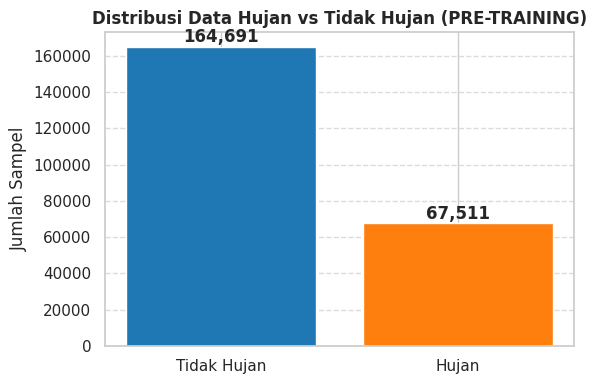

In [5]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (PRE-TRAINING)
# Memplot persentase kejadian hujan (rainrate >= 0.2 mm/jam) pada data pre-training.
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Data Hujan vs Tidak Hujan (PRE-TRAINING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [6]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
# Menghitung indeks diurnal harian dan fitur atmosfer penting seperti dewpoint depression.
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")

    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']

    # Fitur waktu siklikal (cyclic time encoding)
    df_base['sin_hour']  = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour']  = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy']   = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy']   = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    df = df_base.copy()
    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 4.5: Persiapan Parameter LSTM

Sel ini mengatur ukuran jendela sekuens (*lookback window*) yang akan dibaca oleh memori LSTM.

In [7]:
# Sel 6: Setup Parameter Dasar & Split Data LSTM
# Memformat data pre-training menjadi array sekuensial 3D (samples, timesteps, features)
# menggunakan lookback window LOOKBACK=24 jam untuk melatih RNN/LSTM.
import optuna
import gc
from tensorflow.keras import backend as K

logger.info(f"\n{'='*50}\nMEMULAI TRAINING LSTM 1-JAM (OPTUNA HPO)\n{'='*50}")
evaluator = ModelEvaluator()

df_features = engineer_features(df_hourly)
# Target: curah hujan 1 jam ke depan
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= RAIN_THRESHOLD).astype(int)

# 3. Data Split
if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.7)
    val_mask   = (np.arange(n) >= int(n * 0.7)) & (np.arange(n) < int(n * 0.9))
    test_mask  = np.arange(n) >= int(n * 0.9)
else:
    # [PEMBAGIAN DATA PRE-TRAINING BERDASARKAN TANGGAL]
    train_mask = (df_features.index >= PRETRAIN__TRAIN_START) & (df_features.index <= PRETRAIN__TRAIN_END)
    val_mask   = (df_features.index >= PRETRAIN__VAL_START)   & (df_features.index < PRETRAIN__VAL_END)
    test_mask  = (df_features.index >= PRETRAIN__TEST_START)  & (df_features.index <= PRETRAIN__TEST_END)

X     = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

scaler = MinMaxScaler()
scaler.fit(X[train_mask])
X_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)

import joblib
joblib.dump(scaler, evaluator.dirs['models'] / 'pretrain_scaler.pkl')
logger.info(f"Scaler di-fit HANYA pada {X[train_mask].shape[0]} sampel latih. Disimpan ke pretrain_scaler.pkl")

def make_3d(X_df, y_o, y_r, lookback):
    X_arr, yo_arr, yr_arr = [], [], []
    for i in range(len(X_df) - lookback + 1):
        X_arr.append(X_df.iloc[i:i+lookback].values)
        yo_arr.append(y_o.iloc[i+lookback-1])
        yr_arr.append(y_r.iloc[i+lookback-1])
    return (np.array(X_arr, dtype=np.float32),
            np.array(yo_arr, dtype=np.float32),
            np.array(yr_arr, dtype=np.float32))

X_tr_seq, y_tr_o, y_tr_r = make_3d(X_scaled[train_mask], y_occ[train_mask], y_reg[train_mask], LOOKBACK)
X_va_seq, y_va_o, y_va_r = make_3d(X_scaled[val_mask],   y_occ[val_mask],   y_reg[val_mask],   LOOKBACK)
X_te_seq, y_te_o, y_te_r = make_3d(X_scaled[test_mask],  y_occ[test_mask],  y_reg[test_mask],  LOOKBACK)

logger.info(f"Sequence shapes — Train: {X_tr_seq.shape}, Val: {X_va_seq.shape}, Test: {X_te_seq.shape}")
logger.info(f"Distribusi Hujan (Train): {y_tr_o.sum():.0f}/{len(y_tr_o)} ({100*y_tr_o.mean():.1f}%)")
logger.info(f"Distribusi Hujan (Val)  : {y_va_o.sum():.0f}/{len(y_va_o)} ({100*y_va_o.mean():.1f}%)")
logger.info(f"Distribusi Hujan (Test) : {y_te_o.sum():.0f}/{len(y_te_o)} ({100*y_te_o.mean():.1f}%)")



2026-07-14 07:08:49,397 - INFO - 
MEMULAI TRAINING LSTM 1-JAM (OPTUNA HPO)
2026-07-14 07:08:49,399 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-14 07:08:49,520 - INFO - Dimensi akhir setelah rekayasa fitur: (232180, 23)
2026-07-14 07:08:49,613 - INFO - Scaler di-fit HANYA pada 140233 sampel latih. Disimpan ke pretrain_scaler.pkl
2026-07-14 07:08:54,778 - INFO - Sequence shapes — Train: (140210, 24, 23), Val: (26219, 24, 23), Test: (17491, 24, 23)
2026-07-14 07:08:54,779 - INFO - Distribusi Hujan (Train): 41951/140210 (29.9%)
2026-07-14 07:08:54,780 - INFO - Distribusi Hujan (Val)  : 8010/26219 (30.6%)
2026-07-14 07:08:54,781 - INFO - Distribusi Hujan (Test) : 5541/17491 (31.7%)


## Tahap 5: Pelatihan Klasifikasi Hujan (Optuna LSTM)

Di sini model Jaringan Saraf Tiruan (LSTM) dilatih untuk mengenali apakah curah hujan akan mencapai ambang batas (>= 1.0 mm) atau tidak berdasarkan sekuens waktu.

2026-07-14 07:08:54,822 - INFO - Memulai HPO Optuna untuk LSTM Classifier (BiLSTM)...
[I 2026-07-14 07:08:56,551] A new study created in RDB with name: lstm_classifier
I0000 00:00:1784012938.039272      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1784012942.594533      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
[I 2026-07-14 07:12:59,712] Trial 0 finished with value: 0.9441225698467877 and parameters: {'units_l1': 64, 'units_l2': 64, 'lr': 0.00023919241762603168, 'dropout': 0.17081530307399562, 'batch_size': 128}. Best is trial 0 with value: 0.9441225698467877.
[I 2026-07-14 07:17:06,987] Trial 1 finished with value: 0.9439288476411446 and parameters: {'units_l1': 128, 'units_l2': 64, 'lr': 0.0042826175190034815, 'dropout': 0.17322876560975048, 'batch_size': 64}. Best is trial 0 with value: 0.9441225698467877.
[I 2026-

Epoch 1/50
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.3471 - precision: 0.8044 - recall: 0.6222 - val_loss: 0.2265 - val_precision: 0.9519 - val_recall: 0.7407 - learning_rate: 6.5237e-04
Epoch 2/50
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.1690 - precision: 0.9421 - recall: 0.8493 - val_loss: 0.1440 - val_precision: 0.9729 - val_recall: 0.8634 - learning_rate: 6.5237e-04
Epoch 3/50
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.1302 - precision: 0.9651 - recall: 0.8954 - val_loss: 0.1217 - val_precision: 0.9676 - val_recall: 0.9067 - learning_rate: 6.5237e-04
Epoch 4/50
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.1181 - precision: 0.9717 - recall: 0.9078 - val_loss: 0.1180 - val_precision: 0.9755 - val_recall: 0.9092 - learning_rate: 6.5237e-04
Epoch 5/50
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.1126 - precision: 0.9731 - recall: 0.9135 - val_loss: 0.1268 - val_precision: 0.9862 - val_recall: 0.8824 - learning_rate: 6.5237e-04
Epoch

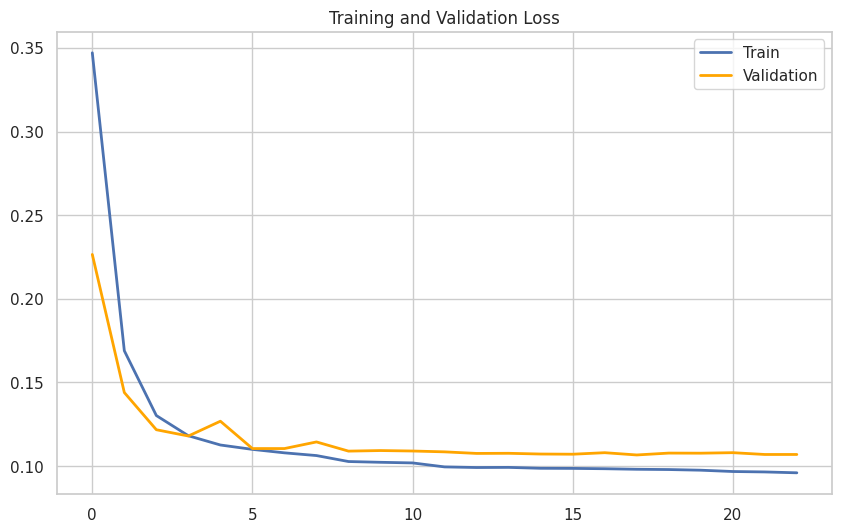

2026-07-14 09:02:37,575 - INFO - [Calibrator Selection] Brier scores - Raw: 0.0277, Platt: 0.0290, Isotonic: 0.0274
2026-07-14 09:02:37,579 - INFO - [Calibrator Selection] Selected Isotonic Calibrator
2026-07-14 09:02:37,659 - INFO - Pre-training Classifier selesai. ECE/MCE tersedia secara global.


In [8]:
from tensorflow import keras
# Sel 7: Optuna Tuning untuk Classifier LSTM
# Mengoptimalkan hyperparameter arsitektur BiLSTM Classifier menggunakan Optuna.
import optuna
from optuna.pruners import MedianPruner
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import gc
from tensorflow.keras import backend as K
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
import joblib

def build_lstm_clf(lookback, units_l1, units_l2, lr, dropout):
    model = Sequential([
        Input(shape=(lookback, X.shape[1])),
        LSTM(units_l1, return_sequences=True),
        Dropout(dropout),
        LSTM(units_l2, return_sequences=False),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr), 
        loss='binary_crossentropy', 
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

def objective_clf(trial):
    K.clear_session()
    gc.collect()
    units_l1   = trial.suggest_categorical('units_l1', [64, 128])
    units_l2   = trial.suggest_categorical('units_l2', [32, 64])
    lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    dropout    = trial.suggest_float('dropout', 0.1, 0.3)
    batch_size = trial.suggest_categorical('batch_size', [64, 128])
    model = build_lstm_clf(LOOKBACK, units_l1, units_l2, lr, dropout)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model.fit(X_tr_seq, y_tr_o, validation_data=(X_va_seq, y_va_o),
              epochs=EPOCHS, batch_size=batch_size, callbacks=[es], verbose=0)
    from sklearn.metrics import f1_score
    val_prob = model.predict(X_va_seq, verbose=0).flatten()
    val_preds = (val_prob >= 0.5).astype(int)
    return f1_score(y_va_o, val_preds, zero_division=0)

logger.info("Memulai HPO Optuna untuk LSTM Classifier (BiLSTM)...")
optuna.logging.set_verbosity(optuna.logging.INFO)
# [AUDIT FIX] MedianPruner menghentikan trial tidak menjanjikan lebih awal
import os
db_path = evaluator.dirs['models'] / 'optuna_lstm.db'
os.makedirs(db_path.parent, exist_ok=True)
storage_url = f"sqlite:///{db_path.as_posix()}"
study_clf = optuna.create_study(
    study_name="lstm_classifier",
    storage=storage_url,
    direction='maximize',
    load_if_exists=True
)
study_clf.optimize(objective_clf, n_trials=OPTUNA_TRIALS)

best_clf_params = study_clf.best_params
logger.info(f"Parameter terbaik Classifier: {best_clf_params}")

K.clear_session()
gc.collect()

clf_best = build_lstm_clf(LOOKBACK, best_clf_params['units_l1'], best_clf_params['units_l2'],
                           best_clf_params['lr'], best_clf_params['dropout'])

# [AUDIT FIX] ModelCheckpoint menyimpan bobot terbaik selama pelatihan akhir (post-HPO)
clf_ckpt_path = str(evaluator.dirs['models_clf'] / 'best_lstm_occ_ckpt.keras')
es        = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
ckpt      = ModelCheckpoint(clf_ckpt_path, monitor='val_loss', save_best_only=True, verbose=0)

history_clf = clf_best.fit(
    X_tr_seq, y_tr_o,
    validation_data=(X_va_seq, y_va_o),
    epochs=EPOCHS,
    batch_size=best_clf_params['batch_size'],
    callbacks=[es, reduce_lr, ckpt],
    verbose=1
)

plt.figure(figsize=(10,6))
plt.plot(history_clf.history['loss'], label='Train')
plt.plot(history_clf.history['val_loss'], label='Validation', color='orange')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig(evaluator.dirs['plots'] / 'training_loss_clf.png', dpi=300)
plt.show()

clf_best.save(evaluator.dirs['models_clf'] / 'best_lstm_occ.keras')

# [AUDIT FIX] Kalibrasi Probabilitas — Isotonic vs Platt Scaling
# Kalibrasi WAJIB menggunakan data Validasi (bukan Test)
val_probs_uncal = clf_best.predict(X_va_seq, verbose=0).flatten()

best_calibrator_pretrain, cal_method_pretrain = fit_best_calibrator(y_va_o, val_probs_uncal)

if best_calibrator_pretrain is not None:
    joblib.dump(best_calibrator_pretrain, evaluator.dirs['models_cal'] / 'isotonic_calibrator.pkl')

# Hitung nilai Brier untuk pencatatan metadata
iso_temp = IsotonicRegression(out_of_bounds='clip').fit(val_probs_uncal, y_va_o)
brier_iso = brier_score_loss(y_va_o, iso_temp.predict(val_probs_uncal))
platt_temp = LogisticRegression().fit(val_probs_uncal.reshape(-1, 1), y_va_o)
brier_platt = brier_score_loss(y_va_o, platt_temp.predict_proba(val_probs_uncal.reshape(-1, 1))[:, 1])

joblib.dump({'method': cal_method_pretrain, 'brier_iso': brier_iso, 'brier_platt': brier_platt},
            evaluator.dirs['models_cal'] / 'calibration_meta.pkl')

logger.info("Pre-training Classifier selesai. ECE/MCE tersedia secara global.")


## Tahap 6: Pelatihan Regresi Intensitas (Optuna LSTM)

Setelah model tahu bahwa akan turun hujan, model *Regressor* ini bertugas menebak **Berapa lebat hujannya?** (dalam satuan milimeter).

2026-07-14 09:02:38,826 - INFO - Memulai HPO Optuna untuk LSTM Regressor (BiLSTM)...
[I 2026-07-14 09:02:38,900] A new study created in RDB with name: lstm_regressor
[I 2026-07-14 09:03:24,168] Trial 0 finished with value: 0.008610949851572514 and parameters: {'units_l1': 128, 'units_l2': 64, 'lr': 0.0005184883967055221, 'dropout': 0.2787656060258633, 'batch_size': 128}. Best is trial 0 with value: 0.008610949851572514.
[I 2026-07-14 09:06:11,905] Trial 1 finished with value: 0.007922360673546791 and parameters: {'units_l1': 64, 'units_l2': 32, 'lr': 0.0003279086993868894, 'dropout': 0.2567741512380491, 'batch_size': 64}. Best is trial 1 with value: 0.007922360673546791.
[I 2026-07-14 09:08:03,784] Trial 2 finished with value: 0.006803879048675299 and parameters: {'units_l1': 64, 'units_l2': 64, 'lr': 0.0007970085437557447, 'dropout': 0.1130147371401775, 'batch_size': 64}. Best is trial 2 with value: 0.006803879048675299.
[I 2026-07-14 09:09:00,523] Trial 3 finished with value: 0.00666

Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0864 - val_loss: 0.0259 - learning_rate: 0.0039
Epoch 2/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0240 - val_loss: 0.0133 - learning_rate: 0.0039
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0162 - val_loss: 0.0108 - learning_rate: 0.0039
Epoch 4/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0131 - val_loss: 0.0091 - learning_rate: 0.0039
Epoch 5/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0120 - val_loss: 0.0088 - learning_rate: 0.0039
Epoch 6/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0113 - val_loss: 0.0091 - learning_rate: 0.0039
Epoch 7/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0109 - val_loss: 0.0083 - learning_rate: 0.0039
Epoch 8/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0105 - val_loss: 0.0084 - learning_rate: 0.0039
Epoch 9/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0104 - val_loss: 0.0077 - learning_rate: 0.0039
Epoch 10/5

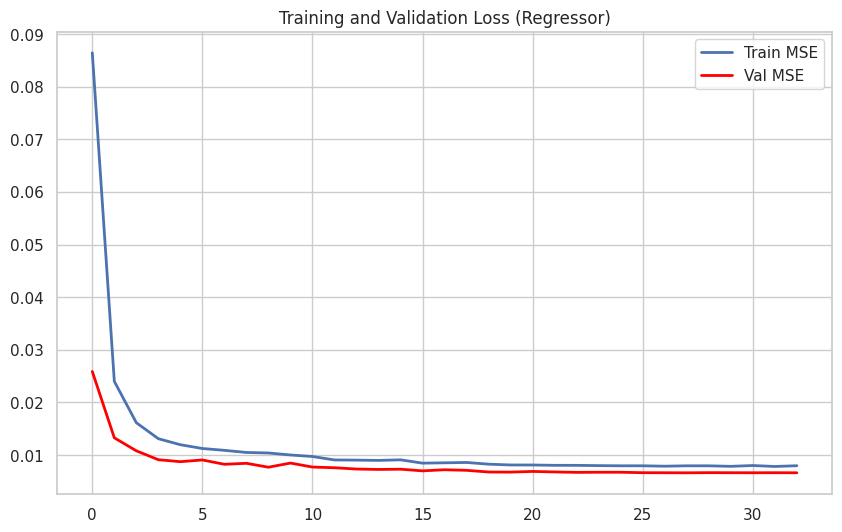

In [9]:
# Sel 8: Optuna Tuning untuk Regressor LSTM
# Mengoptimalkan hyperparameter arsitektur BiLSTM Regressor pada data dengan intensitas positif.
# Hanya melatih data yang aktualnya hujan
import optuna
from optuna.pruners import MedianPruner
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import gc
from tensorflow.keras import backend as K
import joblib

rainy_tr = y_tr_o == 1
rainy_va = y_va_o == 1

if np.sum(rainy_tr) > 10:
    X_tr_r_val, y_tr_r_val = X_tr_seq[rainy_tr], np.log1p(y_tr_r[rainy_tr])
    X_va_r_val, y_va_r_val = X_va_seq[rainy_va], np.log1p(y_va_r[rainy_va])

    def build_lstm_reg(lookback, units_l1, units_l2, lr, dropout):
        model = Sequential([
            Input(shape=(lookback, X.shape[1])),
            LSTM(units_l1, return_sequences=True),
            Dropout(dropout),
            LSTM(units_l2, return_sequences=False),
            Dropout(dropout),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        return model

    def objective_reg(trial):
        K.clear_session()
        gc.collect()
        units_l1   = trial.suggest_categorical('units_l1', [64, 128])
        units_l2   = trial.suggest_categorical('units_l2', [32, 64])
        lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        dropout    = trial.suggest_float('dropout', 0.1, 0.3)
        batch_size = trial.suggest_categorical('batch_size', [64, 128])
        model = build_lstm_reg(LOOKBACK, units_l1, units_l2, lr, dropout)
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(X_tr_r_val, y_tr_r_val, validation_data=(X_va_r_val, y_va_r_val),
                  epochs=EPOCHS, batch_size=batch_size, callbacks=[es], verbose=0)
        val_loss = model.evaluate(X_va_r_val, y_va_r_val, verbose=0)
        return val_loss

    logger.info("Memulai HPO Optuna untuk LSTM Regressor (BiLSTM)...")
    # [AUDIT FIX] MedianPruner untuk efisiensi HPO regressor
    db_path = evaluator.dirs['models'] / 'optuna_lstm.db'
    storage_url = f"sqlite:///{db_path.as_posix()}"
    study_reg = optuna.create_study(
        study_name="lstm_regressor",
        storage=storage_url,
        direction='minimize',
        load_if_exists=True
    )
    study_reg.optimize(objective_reg, n_trials=OPTUNA_TRIALS)

    best_reg_params = study_reg.best_params
    logger.info(f"Parameter terbaik Regressor: {best_reg_params}")

    K.clear_session()
    gc.collect()

    reg_best = build_lstm_reg(LOOKBACK, best_reg_params['units_l1'], best_reg_params['units_l2'],
                               best_reg_params['lr'], best_reg_params['dropout'])

    # [AUDIT FIX] ModelCheckpoint untuk pelatihan akhir regressor
    reg_ckpt_path = str(evaluator.dirs['models_reg'] / 'best_lstm_reg_ckpt.keras')
    es        = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ckpt_reg  = ModelCheckpoint(reg_ckpt_path, monitor='val_loss', save_best_only=True, verbose=0)

    history_reg = reg_best.fit(
        X_tr_r_val, y_tr_r_val,
        validation_data=(X_va_r_val, y_va_r_val),
        epochs=EPOCHS,
        batch_size=best_reg_params['batch_size'],
        callbacks=[es, reduce_lr, ckpt_reg],
        verbose=1
    )

    plt.figure(figsize=(10,6))
    plt.plot(history_reg.history['loss'], label='Train MSE')
    plt.plot(history_reg.history['val_loss'], label='Val MSE', color='red')
    plt.title('Training and Validation Loss (Regressor)')
    plt.legend()
    plt.savefig(evaluator.dirs['plots'] / 'training_loss_reg.png', dpi=300)
    plt.show()

    reg_best.save(evaluator.dirs['models_reg'] / 'best_lstm_reg.keras')
else:
    logger.warning("Tidak cukup sampel hujan untuk melatih regressor.")
    reg_best = None



## FASE 2: FINE-TUNING (Data Aktual Stasiun AWS)

**Tujuan:** Menyelaraskan model dengan kondisi iklim lokal.
Sel ini menukar sumber data dasar menjadi **data pengukuran asli dari Stasiun AWS**, sembari mempertahankan fitur Angin dan Konvektif yang dipinjam secara dinamis dari ERA5.

In [10]:
# Sel 8.5: Pemuatan Data Aktual Stasiun Bumi AWS (Fine-Tuning)
# Memuat data stasiun AWS bumi dan memperbarui fitur dasar ERA5 menggunakan data observasi darat.
# Pemuatan Data dan Penyatuan (Data Loading & Merge)
import os
from pathlib import Path
import pandas as pd
import numpy as np
import logging

logger.info("Mendeteksi Environment & Memuat data AWS untuk Fine-Tuning...")

if os.path.exists('/kaggle/input'):
    import glob
    sat_search = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
    station_search = glob.glob('/kaggle/input/**/id-05_clear_data_hourly.csv', recursive=True)
    if sat_search:
        SAT_DIR = Path(sat_search[0]).parent
    else:
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
    if station_search:
        STATION_FILE = Path(station_search[0])
    else:
        STATION_FILE = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Stasiun/id-05_clear_data_hourly.csv')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    STATION_FILE  = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit' / 'id-05_clear_data_hourly.csv'
    SAT_DIR       = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat Data Stasiun AWS Lokal
df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_utc'], utc=True)
df_station = df_station.set_index('timestamp').sort_index()
cols_to_keep = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
df_station = df_station[[c for c in cols_to_keep if c in df_station.columns]]

# 2. Memuat ERA5
df_era5 = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5.columns:
    df_era5['timestamp'] = pd.to_datetime(df_era5['datetime_utc'], utc=True)
else:
    df_era5['timestamp'] = pd.to_datetime(df_era5['unixtime'], unit='s', utc=True)
df_era5 = df_era5.set_index('timestamp').sort_index()

df_merged = df_era5.copy()
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_era5.columns:
        df_merged[new_name] = df_era5[raw_col]

# Hapus noise drizzle efek ERA5 (WMO wet-day threshold 0.1 mm/h)
if 'rainrate' in df_merged.columns:
    df_merged['rainrate'] = np.where(df_merged['rainrate'] >= 0.1, df_merged['rainrate'], 0.0)

selected_features = list(ERA5_FEATURES_MAPPING.values())
df_merged = df_merged[[c for c in selected_features if c in df_merged.columns]]

# [REPLACEMENT AWS] Di mana AWS ada, timpa ERA5
df_merged.update(df_station)

# [AUDIT FIX] Filter mulai 2023 (bukan 2025) untuk mencakup split fine-tuning 2023-2024
df_merged = df_merged[df_merged.index >= '2024-12-01']

drop_subset = ['temperature'] if 'temperature' in df_merged.columns else None
df_hourly = df_merged.dropna(subset=drop_subset).copy() if drop_subset else df_merged.dropna().copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data terpadu (FINE-TUNING): {df_hourly.shape}")


2026-07-14 09:40:35,425 - INFO - Mendeteksi Environment & Memuat data AWS untuk Fine-Tuning...
2026-07-14 09:40:36,764 - INFO - Dimensi data terpadu (FINE-TUNING): (13778, 13)


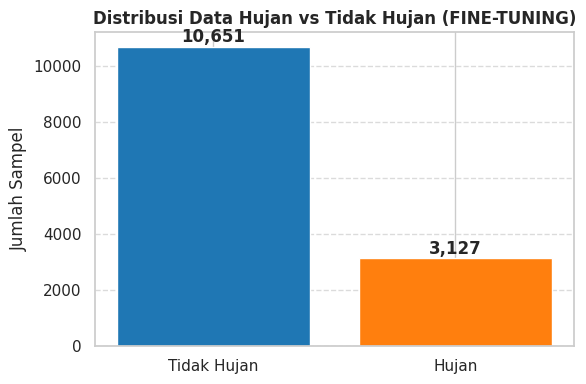

In [11]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (FINE-TUNING)
# Memantau proporsi kejadian hujan stasiun bumi AWS pada data fine-tuning.
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Data Hujan vs Tidak Hujan (FINE-TUNING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [12]:
# Sel 9: Rekayasa Fitur Fisika Atmosfer (Fine-Tuning)
# Menghitung ulang fitur temporal lag dan dewpoint depression pada data AWS.
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")

    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']

    # Fitur waktu siklikal (cyclic time encoding)
    df_base['sin_hour']  = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour']  = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy']   = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy']   = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    df = df_base.copy()
    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 4.75: Pembentukan Sekuens Data Waktu

Mengubah data tabular (2D) menjadi format sekuens (3D) `[samples, timesteps, features]` yang disyaratkan oleh arsitektur LSTM.

In [13]:
# Sel 9.5: Preparasi Sequence dan Split Data (FINE-TUNING)
# Memformat dataset fine-tuning menjadi sekuens temporal 3D (samples, LOOKBACK=24, features) untuk update model.
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
import pandas as pd
import joblib

df_features = engineer_features(df_hourly)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()

# [PEMBAGIAN DATA FINE-TUNING BERDASARKAN TANGGAL]
if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.6)
    val_mask   = (np.arange(n) >= int(n * 0.6)) & (np.arange(n) < int(n * 0.8))
    test_mask  = np.arange(n) >= int(n * 0.8)
else:
    train_mask = (df_features.index >= FINETUNE_TRAIN_START) & (df_features.index <= FINETUNE_TRAIN_END)
    val_mask   = (df_features.index >= FINETUNE_VAL_START)   & (df_features.index < FINETUNE_VAL_END)
    test_mask  = (df_features.index >= FINETUNE_TEST_START)  & (df_features.index <= FINETUNE_TEST_END)

y_all_r = df_features['target_amount'].values
y_all_o = (y_all_r >= RAIN_THRESHOLD).astype(int)

# Load pre-trained MinMaxScaler (hanya transform, tidak re-fit)
scaler = joblib.load(evaluator.dirs['models'] / 'pretrain_scaler.pkl')
X_all_df = df_features.drop(columns=['target_amount'])

# Selaraskan kolom dengan fitur pre-training; isi kolom yang hilang dengan 0
X_all_df = X_all_df.reindex(columns=scaler.feature_names_in_, fill_value=0.0)
X_scaled = scaler.transform(X_all_df)

# [AUDIT FIX] Perbaikan Alignment Mask Sekuens:
# Menggunakan pendekatan blok independen per split (identik dengan pre-training make_3d).
# Ini menggantikan create_sequences(full_array) + mask[LOOKBACK:] yang rentan offset.
X_all_pd = pd.DataFrame(X_scaled, index=df_features.index, columns=scaler.feature_names_in_)
y_o_pd   = pd.Series(y_all_o, index=df_features.index)
y_r_pd   = pd.Series(y_all_r, index=df_features.index)

def make_3d_np(X_df, y_o, y_r, lookback):
    Xv, yov, yrv = X_df.values, y_o.values, y_r.values
    X_arr, yo_arr, yr_arr = [], [], []
    for i in range(len(Xv) - lookback + 1):
        X_arr.append(Xv[i:i+lookback])
        yo_arr.append(yov[i+lookback-1])
        yr_arr.append(yrv[i+lookback-1])
    return (np.array(X_arr, dtype=np.float32),
            np.array(yo_arr, dtype=np.float32),
            np.array(yr_arr, dtype=np.float32))

X_tr_seq, y_tr_o, y_tr_r = make_3d_np(X_all_pd[train_mask], y_o_pd[train_mask], y_r_pd[train_mask], LOOKBACK)
X_v_seq,  y_v_o,  y_v_r  = make_3d_np(X_all_pd[val_mask],   y_o_pd[val_mask],   y_r_pd[val_mask],   LOOKBACK)
X_te_seq, y_te_o, y_te_r = make_3d_np(X_all_pd[test_mask],  y_o_pd[test_mask],  y_r_pd[test_mask],  LOOKBACK)

logger.info(f"Fine-Tuning Sequence — Train: {X_tr_seq.shape}, Val: {X_v_seq.shape}, Test: {X_te_seq.shape}")
logger.info(f"Distribusi Hujan (Train): {y_tr_o.sum():.0f}/{len(y_tr_o)} ({100*y_tr_o.mean():.1f}%)")
logger.info(f"Distribusi Hujan (Val)  : {y_v_o.sum():.0f}/{len(y_v_o)} ({100*y_v_o.mean():.1f}%)")
logger.info(f"Distribusi Hujan (Test) : {y_te_o.sum():.0f}/{len(y_te_o)} ({100*y_te_o.mean():.1f}%)")


2026-07-14 09:40:40,028 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-14 09:40:40,042 - INFO - Dimensi akhir setelah rekayasa fitur: (13777, 23)
2026-07-14 09:40:40,077 - INFO - Fine-Tuning Sequence — Train: (9074, 24, 23), Val: (1873, 24, 23), Test: (1298, 24, 23)
2026-07-14 09:40:40,078 - INFO - Distribusi Hujan (Train): 1456/9074 (16.0%)
2026-07-14 09:40:40,078 - INFO - Distribusi Hujan (Val)  : 652/1873 (34.8%)
2026-07-14 09:40:40,079 - INFO - Distribusi Hujan (Test) : 133/1298 (10.2%)


## Tahap Terakhir: Proses Fine-Tuning & Perbandingan Model (LSTM)

Di tahap ini, bobot dari model LSTM global digunakan sebagai basis (Pre-trained) dan di-*retrain* secara hati-hati menggunakan dataset lokal (AWS). Laporan komparasi performa akan dicetak secara otomatis.

2026-07-14 09:40:41,401 - INFO - Memuat model terbaik pre-training...


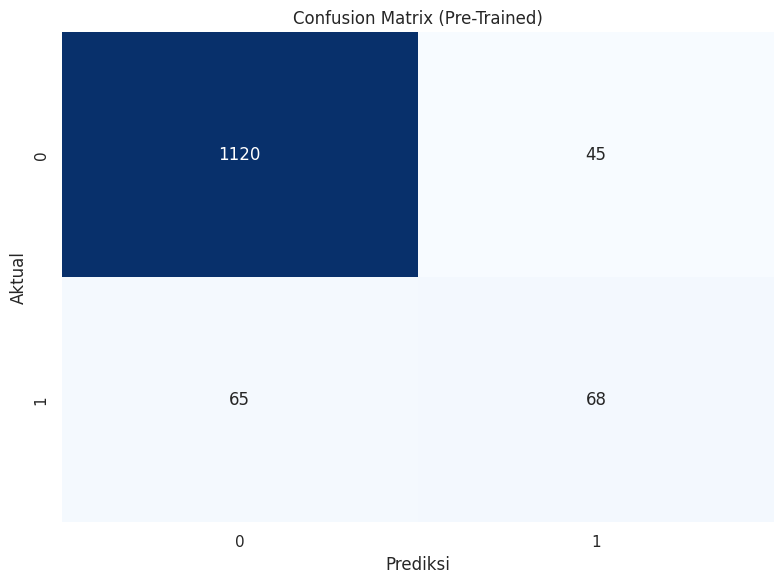

2026-07-14 09:40:42,701 - INFO - Memulai Fine-Tuning LSTM Classifier...


Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3667 - precision: 0.6869 - recall: 0.4279 - val_loss: 0.6076 - val_precision: 0.7025 - val_recall: 0.3006
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2824 - precision: 0.7577 - recall: 0.4876 - val_loss: 0.6086 - val_precision: 0.6942 - val_recall: 0.2960
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2662 - precision: 0.7745 - recall: 0.5309 - val_loss: 0.5613 - val_precision: 0.6484 - val_recall: 0.4724
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2536 - precision: 0.8067 - recall: 0.5591 - val_loss: 0.6246 - val_precision: 0.6742 - val_recall: 0.3206
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2588 - precision: 0.7886 - recall: 0.5536 - val_loss: 0.5924 - val_precision: 0.6700 - val_recall: 0.3083
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2488 - precision: 0.7926 - recall: 0.5749 - val_loss: 0.6388 - val_precision: 0.6761 - val_recall

2026-07-14 09:40:52,313 - WARNING - 5 out of the last 47 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7de4f6960c20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2026-07-14 09:40:52,621 - INFO - [Calibrator Selection] Brier scores - Raw: 0.1866, Platt: 0.1846, Isotonic: 0.1781
2026-07-14 09:40:52,624 - INFO - [Calibrator Selection] Selected Isotonic Calibrator
2026-07-14 09:40:52,628 - INFO - Memulai Fine-Tuning Regres

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4234 - val_loss: 0.2546
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3610 - val_loss: 0.2575
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3552 - val_loss: 0.2588
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3511 - val_loss: 0.2633


2026-07-14 09:40:55,521 - INFO - Menghitung metrik klasifikasi...


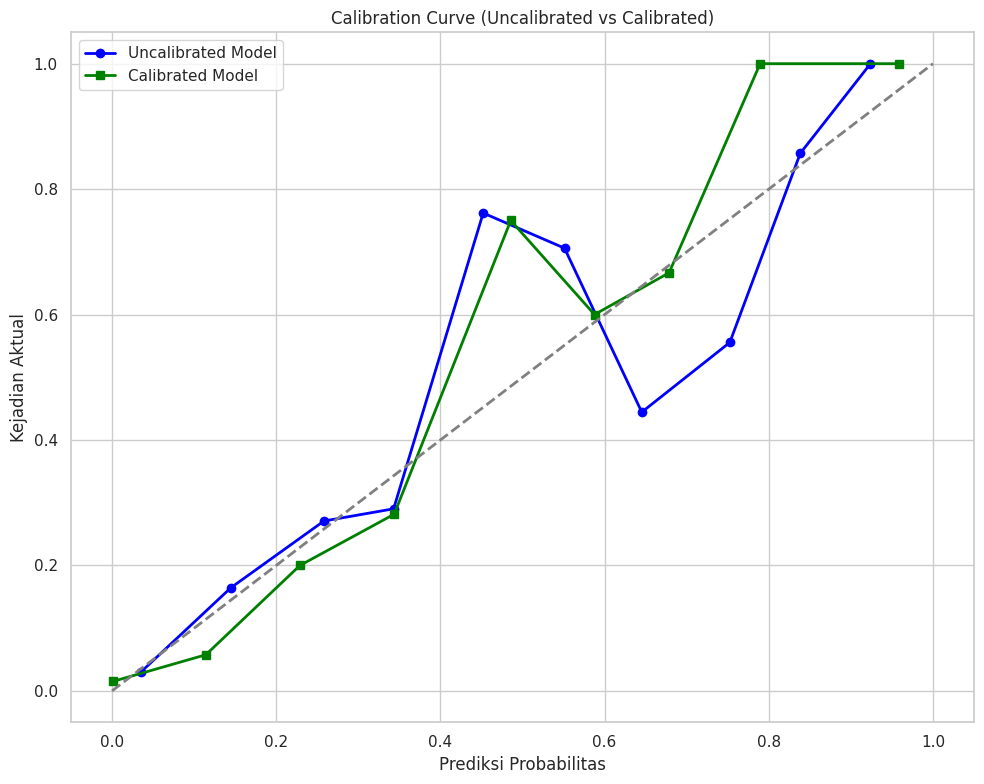

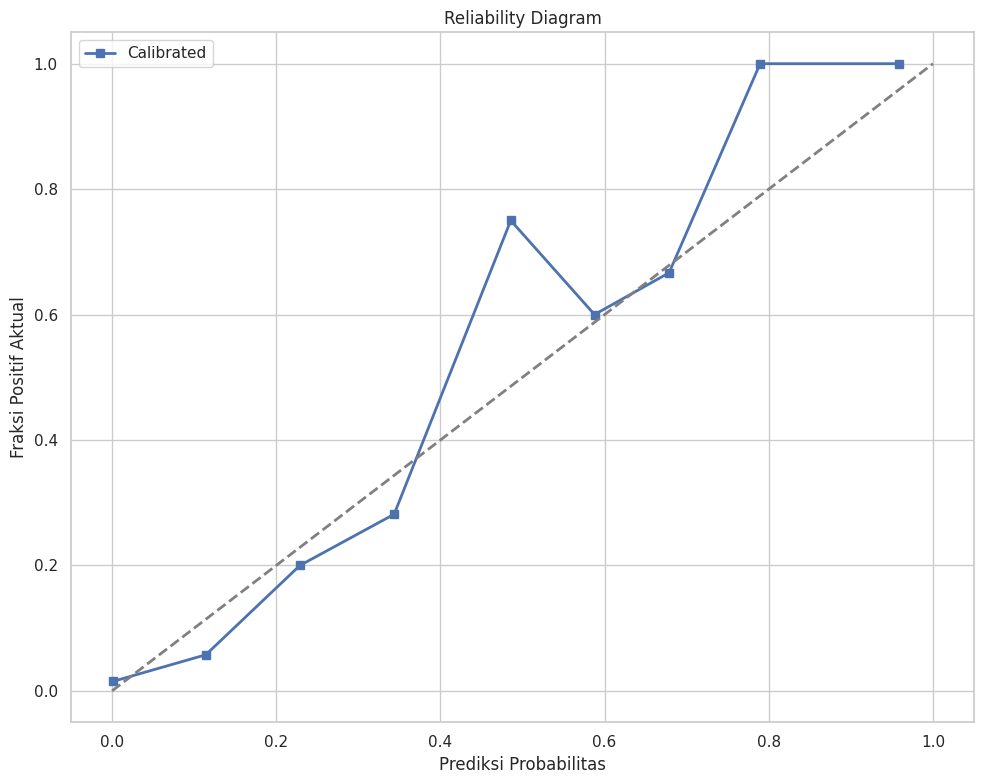

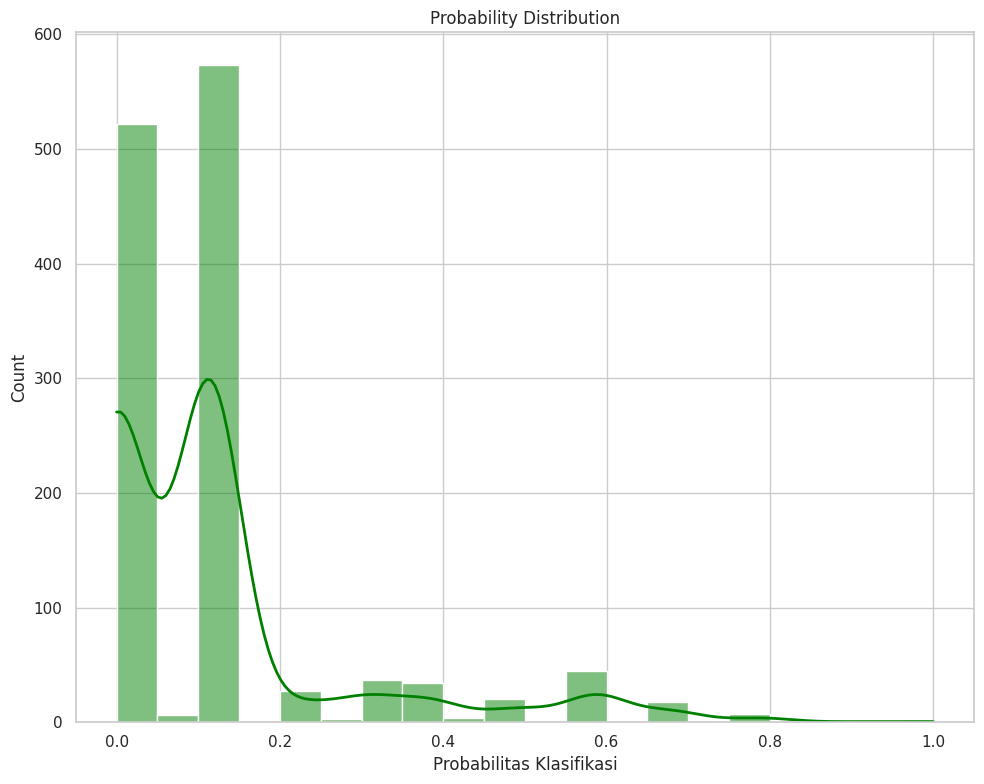

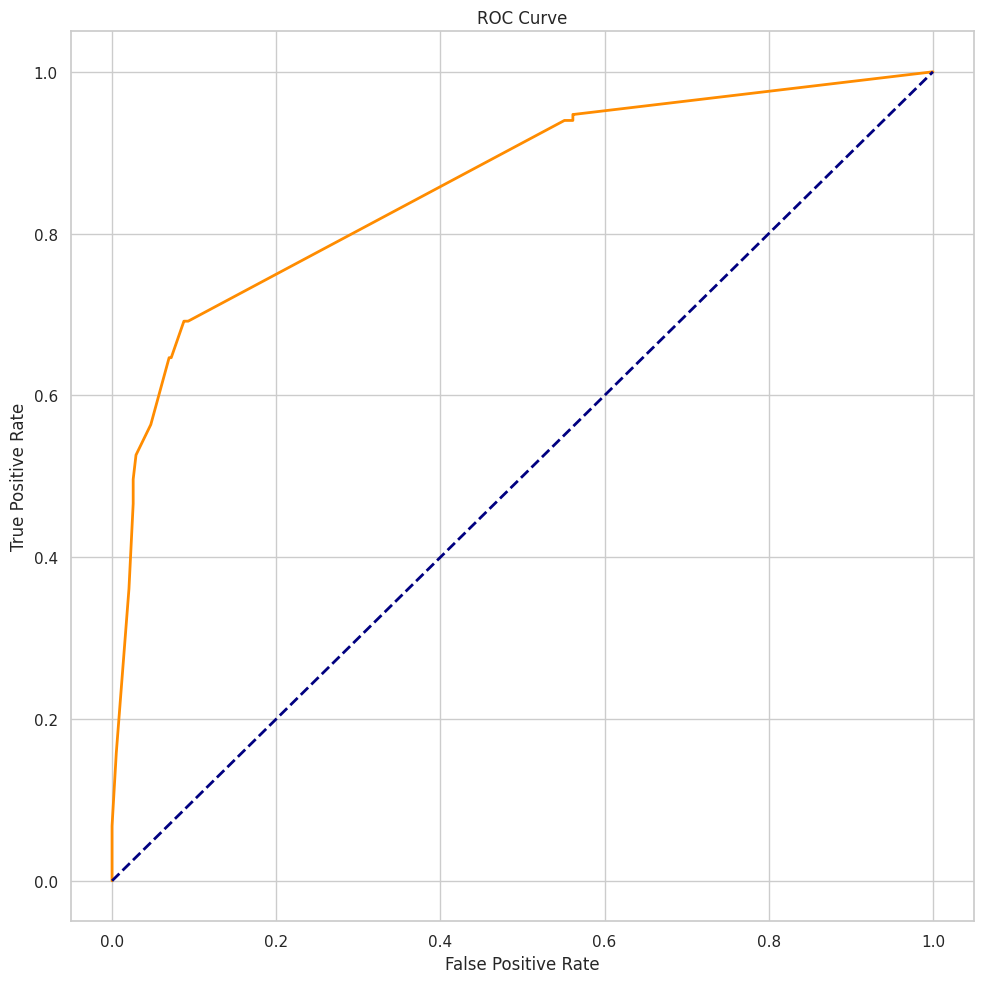

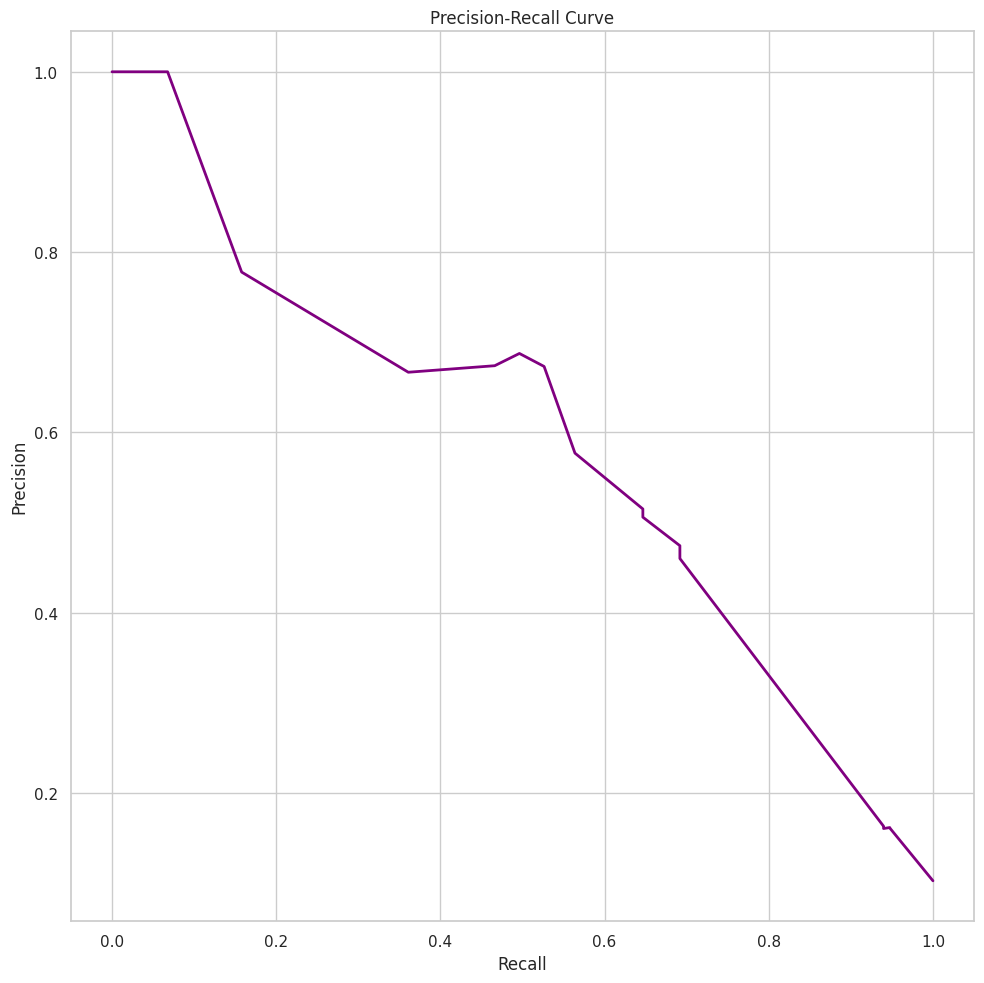

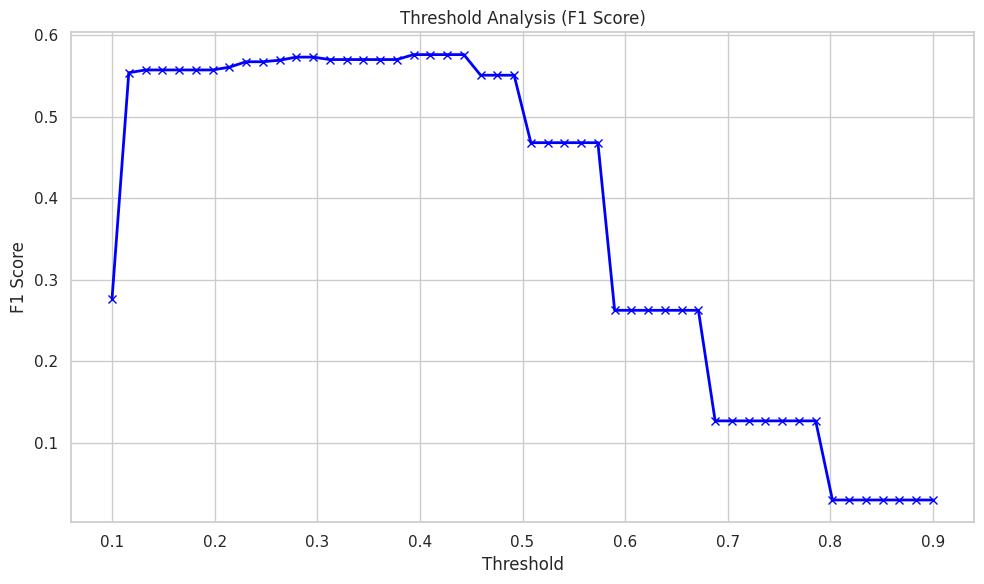

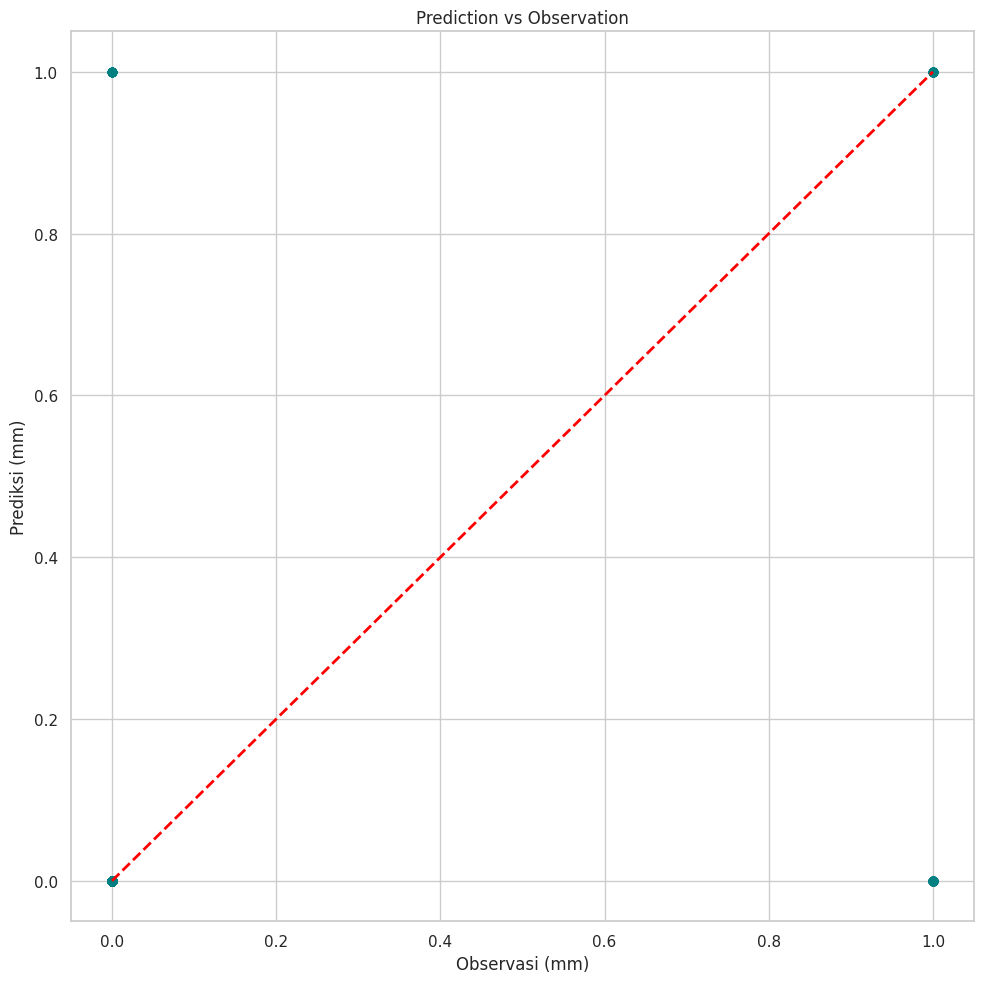

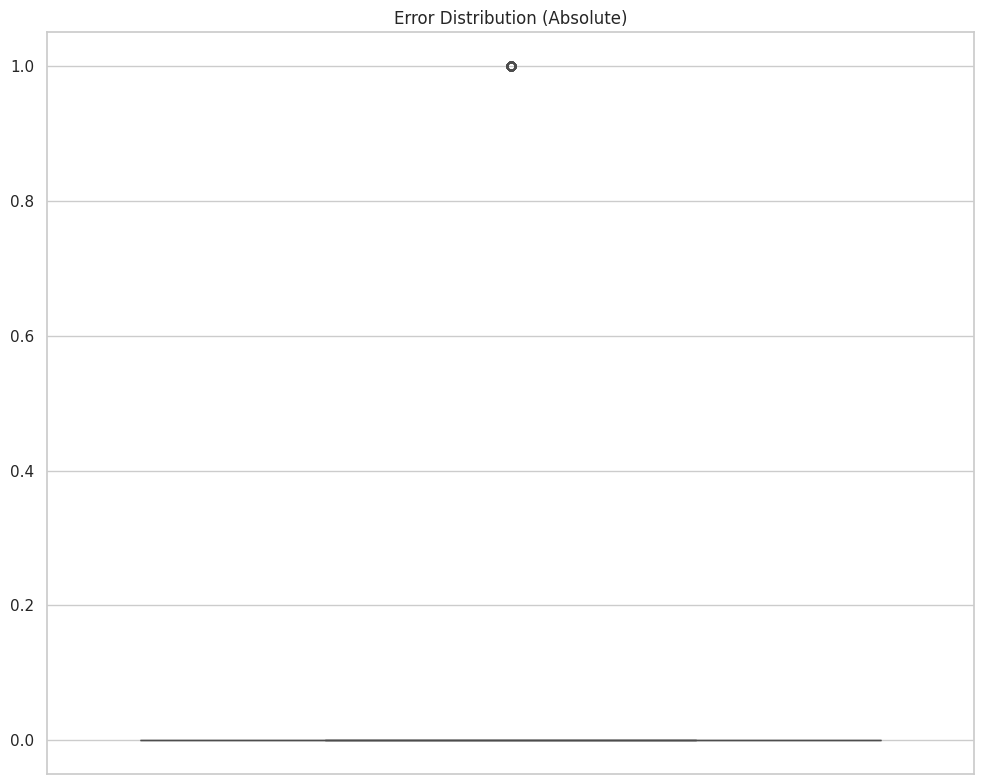

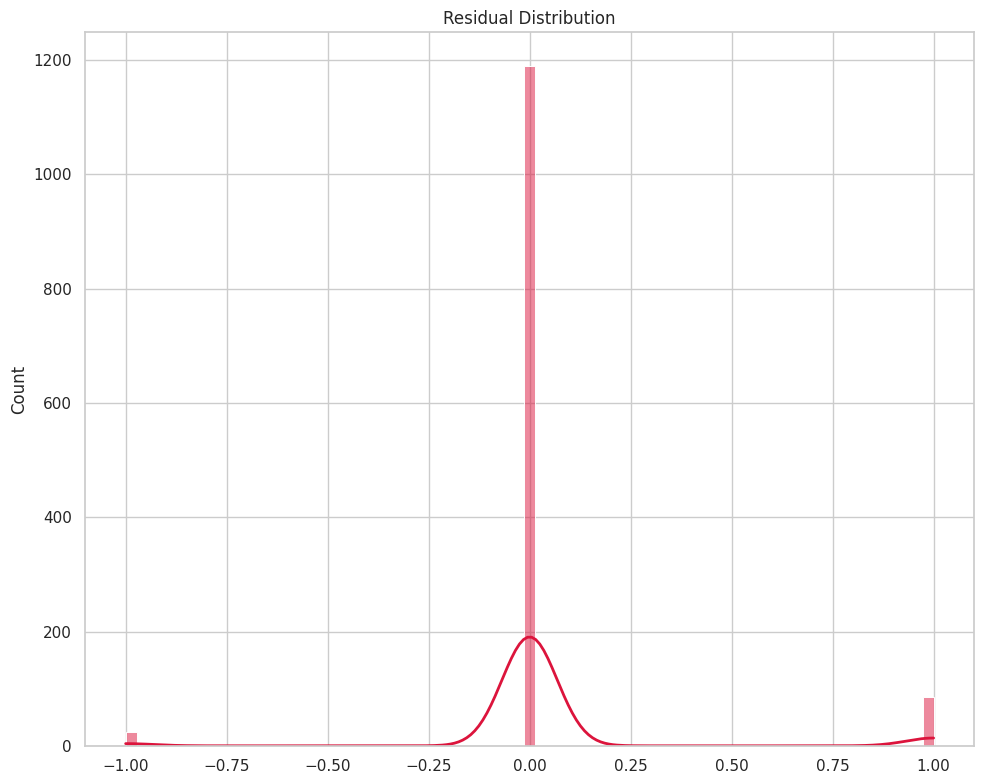

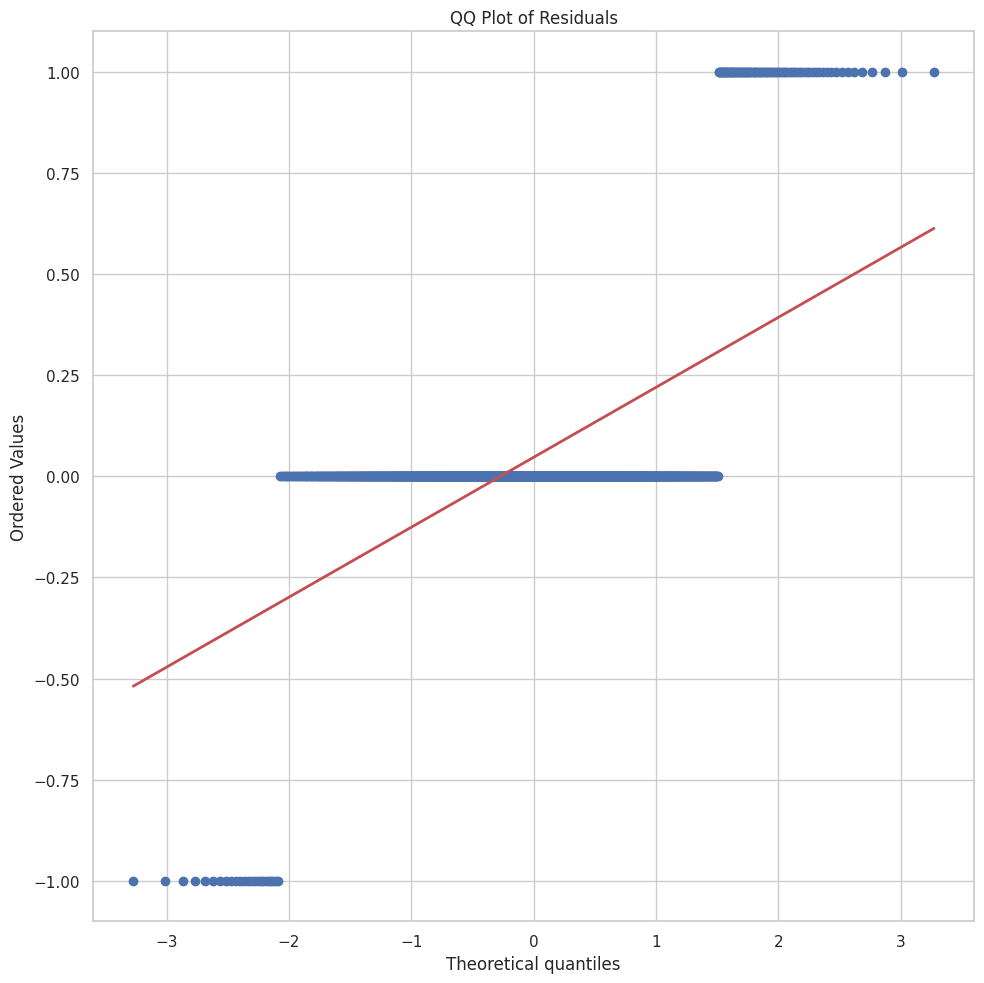

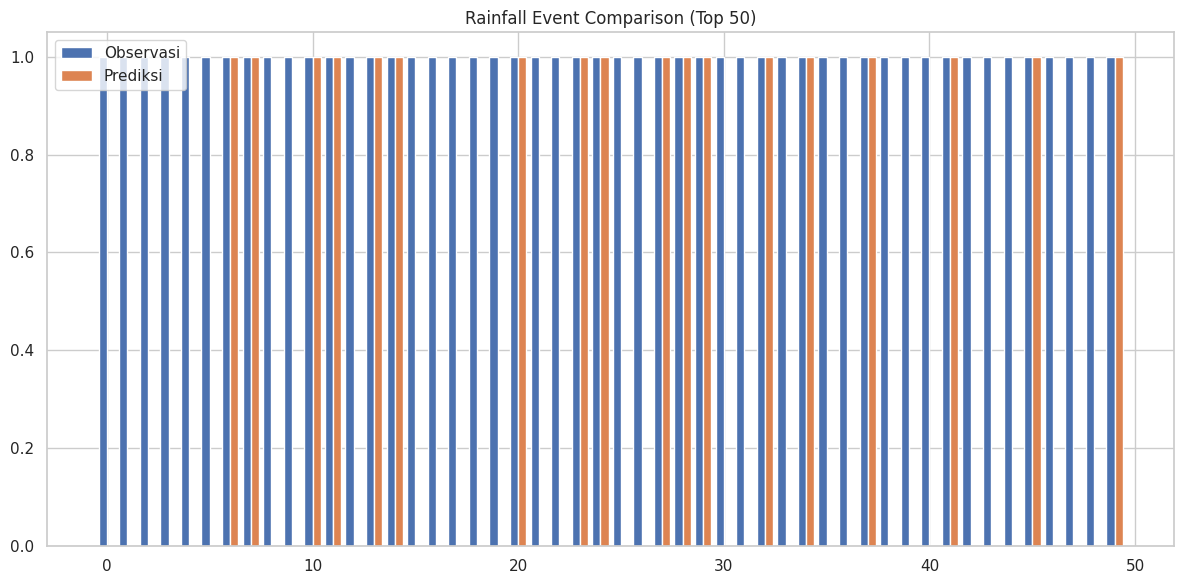

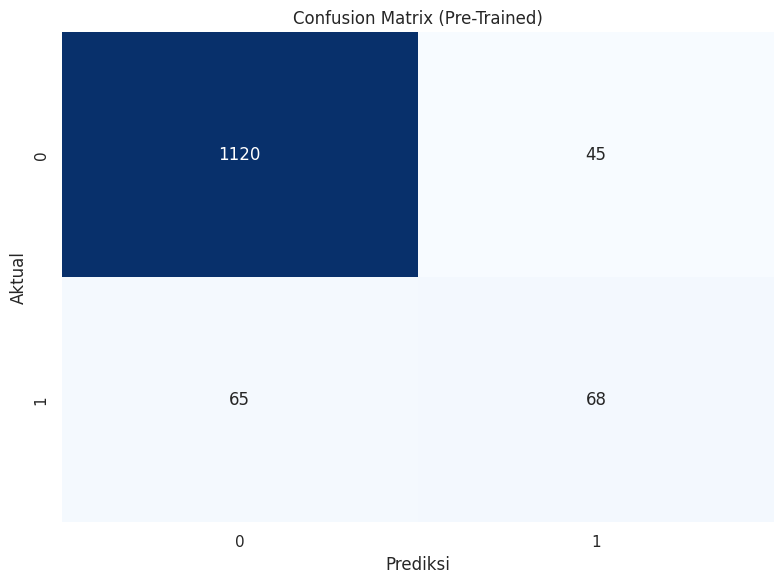

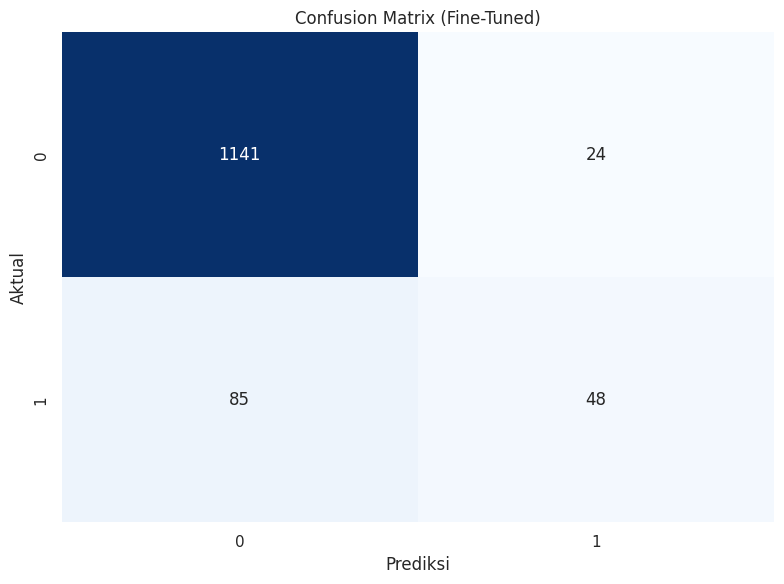

2026-07-14 09:41:03,814 - INFO - Kalibrasi Test — ECE: 0.0414 | MCE: 0.2643
2026-07-14 09:41:04,151 - INFO - Menghitung metrik regresi...


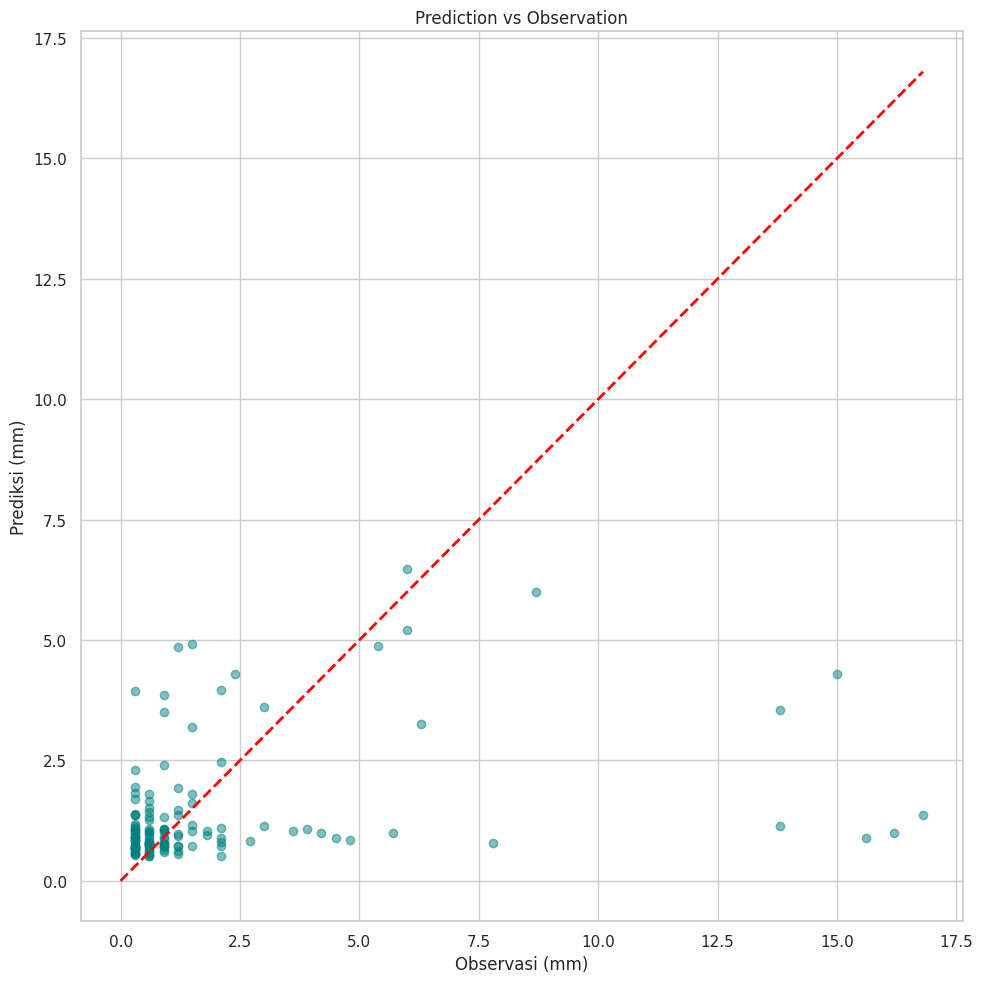

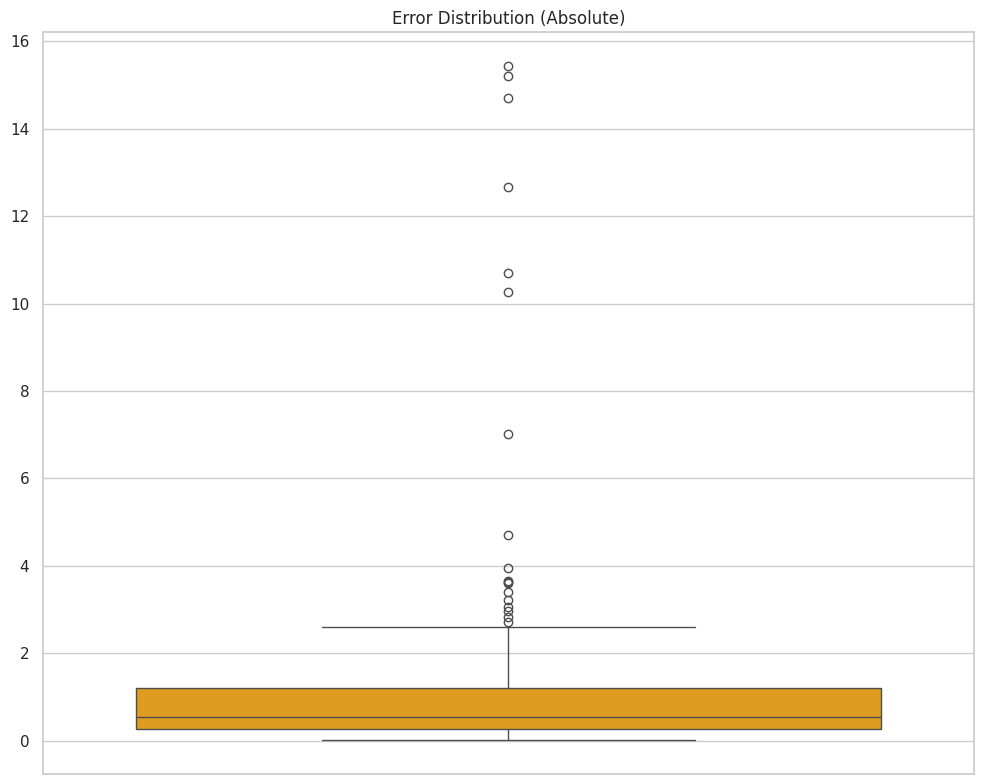

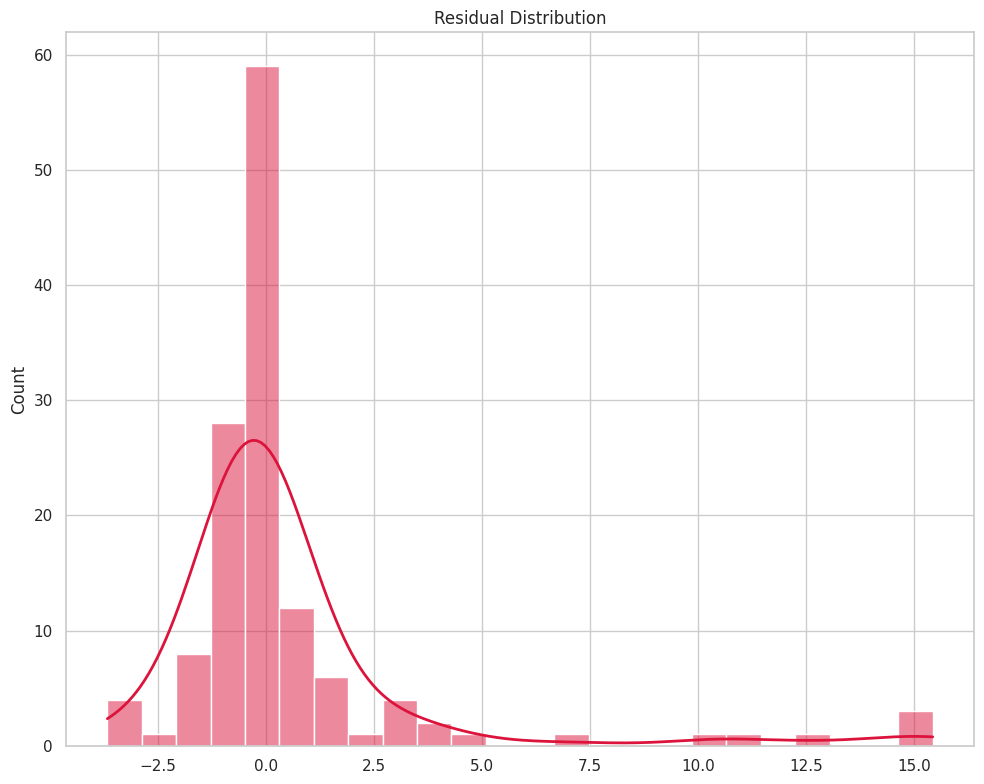

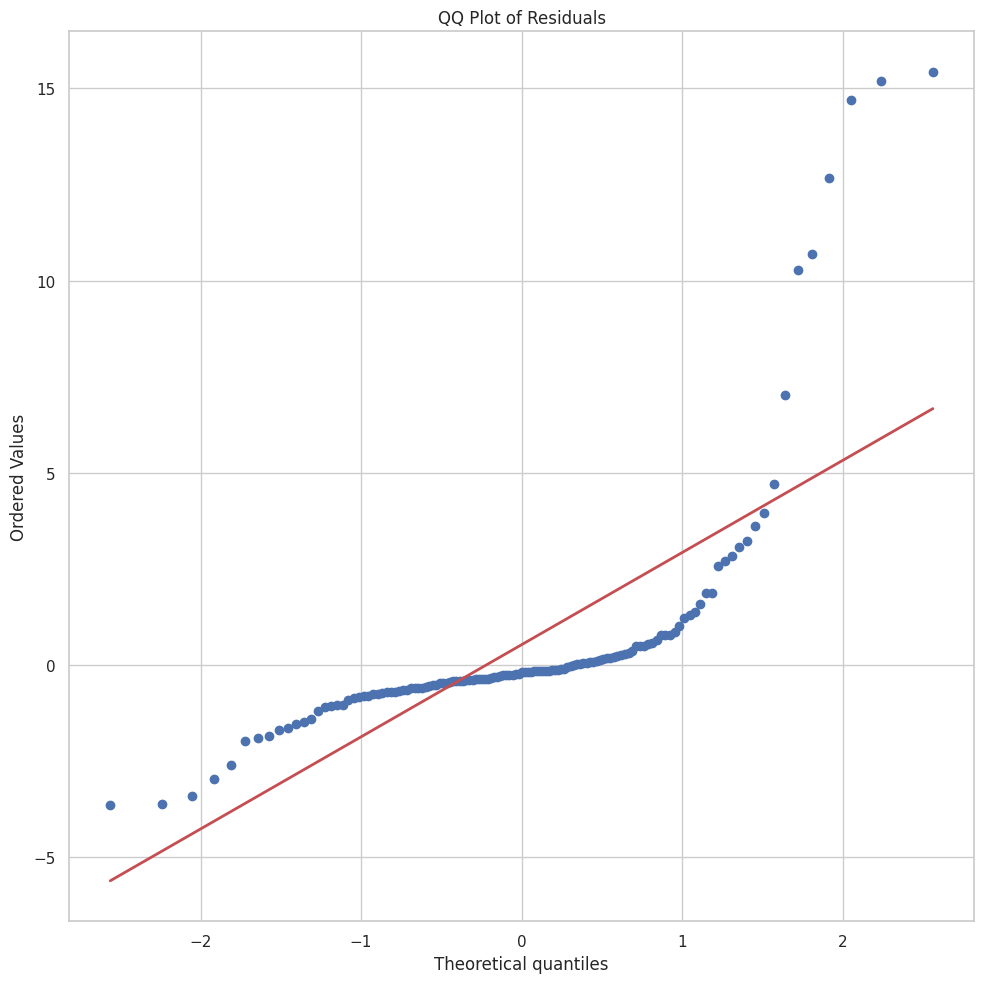

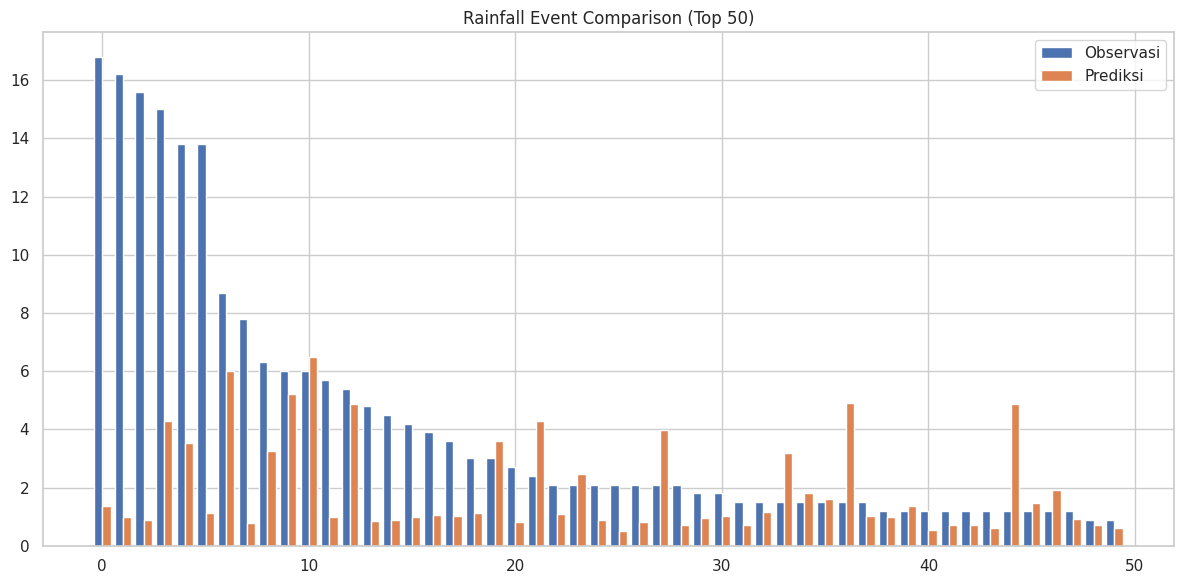

2026-07-14 09:41:07,463 - INFO - Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned (LSTM)...


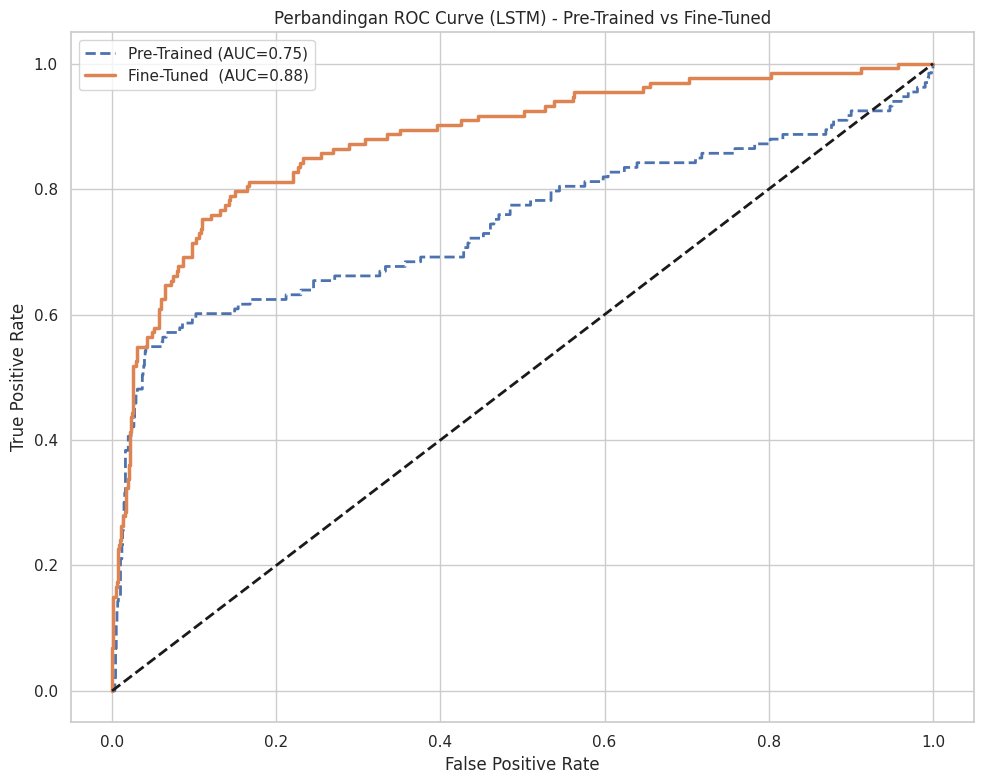

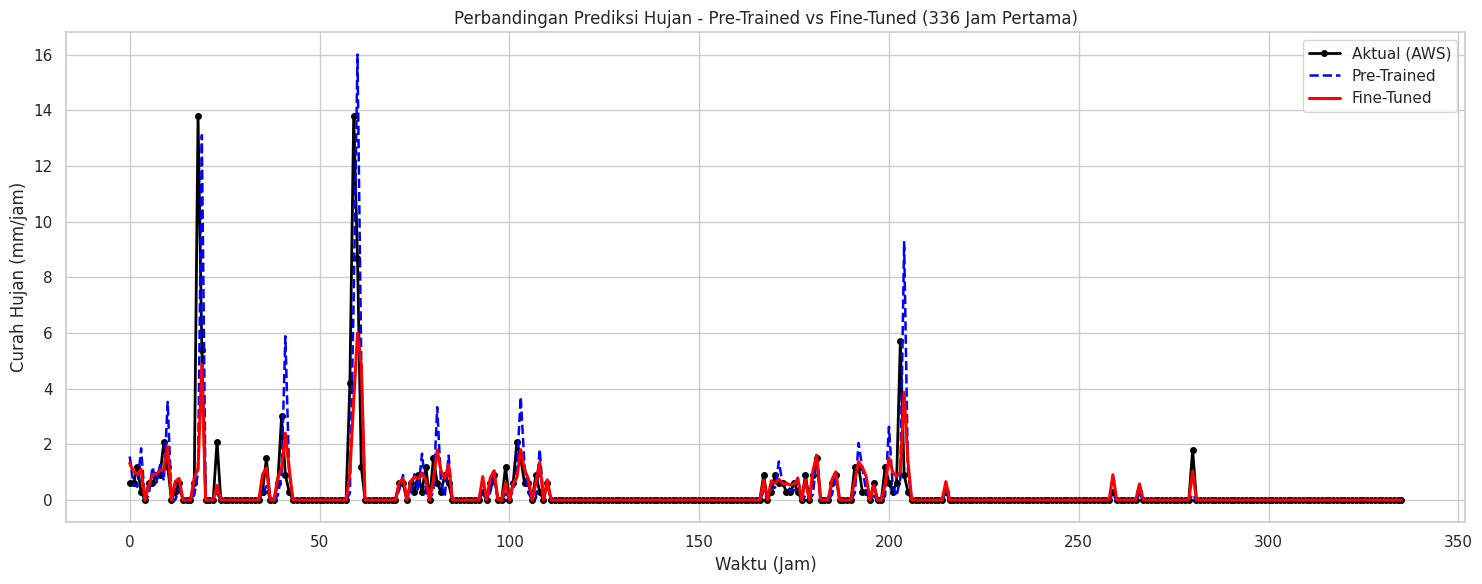

2026-07-14 09:41:08,958 - INFO - Unified Pipeline Selesai!


In [14]:
# Sel 13: Proses Fine-Tuning & Perbandingan Model (LSTM)
# Melatih ulang model dasar (Classifier & Regressor LSTM) secara warm-start menggunakan data stasiun AWS,
# menyetel ulang kalibrator optimal, memprediksi set data uji, dan menghasilkan laporan perbandingan HD.
import joblib
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. LOAD MODEL TERBAIK PRE-TRAINING
logger.info("Memuat model terbaik pre-training...")
clf_best = tf.keras.models.load_model(evaluator.dirs['models_clf'] / 'best_lstm_occ.keras')
reg_best = None
if (evaluator.dirs['models_reg'] / 'best_lstm_reg.keras').exists():
    reg_best = tf.keras.models.load_model(evaluator.dirs['models_reg'] / 'best_lstm_reg.keras')

# 2. EVALUASI BEFORE TUNING (Pre-trained Model pada Test AWS)
pre_test_probs = clf_best.predict(X_te_seq, verbose=0).flatten()
calibrator_pre = joblib.load(evaluator.dirs['models_cal'] / 'isotonic_calibrator.pkl')
cal_meta_pre = joblib.load(evaluator.dirs['models_cal'] / 'calibration_meta.pkl')
pre_test_probs_cal = apply_calibrator(calibrator_pre, cal_meta_pre['method'], pre_test_probs)
pre_test_preds = (pre_test_probs_cal >= 0.5).astype(int)

pre_test_preds_r = np.zeros(len(y_te_o))
rainy_te = y_te_o == 1
if reg_best is not None and np.sum(rainy_te) > 0:
    pre_test_preds_r[rainy_te] = np.clip(
        np.expm1(reg_best.predict(X_te_seq[rainy_te], verbose=0).flatten()), 0, None)

evaluator.plot_confusion_matrix(y_te_o, pre_test_preds, suffix='(Pre-Trained)')

# 3. PROSES FINE-TUNING CLASSIFIER (Learning Rate = 0.01)
logger.info("Memulai Fine-Tuning LSTM Classifier...")
clf_best.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

batch_size_ft = 64
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (tf.data.Dataset
    .from_tensor_slices((X_tr_seq, y_tr_o))
    .shuffle(buffer_size=len(X_tr_seq), seed=SEED)
    .batch(batch_size_ft)
    .cache()
    .prefetch(AUTOTUNE))
val_ds = (tf.data.Dataset
    .from_tensor_slices((X_v_seq, y_v_o))
    .batch(batch_size_ft)
    .cache()
    .prefetch(AUTOTUNE))

clf_ft_ckpt = str(evaluator.dirs['models_clf'] / 'best_lstm_occ_finetuned_ckpt.keras')
es      = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
ckpt_ft = ModelCheckpoint(clf_ft_ckpt, monitor='val_loss', save_best_only=True, verbose=0)

history_clf_ft = clf_best.fit(train_ds, validation_data=val_ds,
                               epochs=EPOCHS, callbacks=[es, ckpt_ft], verbose=1)
clf_best.save(evaluator.dirs['models_clf'] / 'best_lstm_occ_finetuned.keras')

# Kalibrasi ulang menggunakan data validasi fine-tuning
val_probs_uncal = clf_best.predict(X_v_seq, verbose=0).flatten()
iso_reg, cal_method_ft = fit_best_calibrator(y_v_o, val_probs_uncal)
if iso_reg is not None:
    joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator_finetuned.pkl')

rainy_tr = y_tr_o == 1
rainy_v  = y_v_o  == 1

if np.sum(rainy_tr) > 10 and reg_best is not None:
    logger.info("Memulai Fine-Tuning Regressor...")
    X_tr_r_val = X_tr_seq[rainy_tr]
    y_tr_r_val = np.log1p(y_tr_r[rainy_tr])
    X_v_r_val  = X_v_seq[rainy_v]
    y_v_r_val  = np.log1p(y_v_r[rainy_v])

    reg_best.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

    train_reg_ds = (tf.data.Dataset
        .from_tensor_slices((X_tr_r_val, y_tr_r_val))
        .shuffle(buffer_size=len(X_tr_r_val), seed=SEED)
        .batch(batch_size_ft)
        .cache()
        .prefetch(AUTOTUNE))
    val_reg_ds = (tf.data.Dataset
        .from_tensor_slices((X_v_r_val, y_v_r_val))
        .batch(batch_size_ft)
        .cache()
        .prefetch(AUTOTUNE))

    reg_ft_ckpt = str(evaluator.dirs['models_reg'] / 'best_lstm_reg_finetuned_ckpt.keras')
    es_reg      = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ckpt_reg_ft = ModelCheckpoint(reg_ft_ckpt, monitor='val_loss', save_best_only=True, verbose=0)

    history_reg_ft = reg_best.fit(train_reg_ds, validation_data=val_reg_ds,
                                   epochs=EPOCHS, callbacks=[es_reg, ckpt_reg_ft], verbose=1)
    reg_best.save(evaluator.dirs['models_reg'] / 'best_lstm_reg_finetuned.keras')

# 4. EVALUASI AFTER TUNING
test_probs_uncal = clf_best.predict(X_te_seq, verbose=0).flatten()
test_probs_cal = apply_calibrator(iso_reg, cal_method_ft, test_probs_uncal)
test_preds_occ = (test_probs_cal >= 0.5).astype(int)

clf_metrics, meteo_metrics = evaluator.evaluate_classification(
    y_te_o, test_probs_uncal, test_probs_cal, test_preds_occ)
evaluator.plot_confusion_matrix(y_te_o, pre_test_preds, suffix='(Pre-Trained)')
evaluator.plot_confusion_matrix(y_te_o, test_preds_occ, suffix='(Fine-Tuned)')

# Hitung ECE dan MCE pada data Test
ece_val, mce_val = compute_ece_mce(y_te_o, test_probs_cal)
logger.info(f"Kalibrasi Test — ECE: {ece_val:.4f} | MCE: {mce_val:.4f}")
clf_metrics['ECE'] = ece_val
clf_metrics['MCE'] = mce_val

test_preds_r = np.zeros(len(y_te_o))
reg_metrics = {}
if reg_best is not None and np.sum(rainy_te) > 0:
    test_preds_r[rainy_te] = np.clip(
        np.expm1(reg_best.predict(X_te_seq[rainy_te], verbose=0).flatten()), 0, None)
    reg_metrics = evaluator.evaluate_regression(y_te_r[rainy_te], test_preds_r[rainy_te])

# 5. PLOTTING PERBANDINGAN (Before vs After) - DIPISAH MENJADI PLOT MANDIRI DAN HD
logger.info("Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned (LSTM)...")
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot 1: Classification ROC Curve (HD)
plt.figure(figsize=(10, 8))
fpr_pre,  tpr_pre,  _ = roc_curve(y_te_o, pre_test_probs)
fpr_post, tpr_post, _ = roc_curve(y_te_o, test_probs_uncal)

plt.plot(fpr_pre,  tpr_pre,  label=f'Pre-Trained (AUC={auc(fpr_pre,tpr_pre):.2f})',  linestyle='--', linewidth=2.0)
plt.plot(fpr_post, tpr_post, label=f'Fine-Tuned  (AUC={auc(fpr_post,tpr_post):.2f})', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Perbandingan ROC Curve (LSTM) - Pre-Trained vs Fine-Tuned')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'finetuning_comparison_roc.png', dpi=300)
plt.show()
plt.close()

# Plot 2: Timeseries Prediction Comparison (HD)
plt.figure(figsize=(15, 6))
start_idx = 0
end_idx   = min(336, len(y_te_r))

plt.plot(y_te_r[start_idx:end_idx],         label='Aktual (AWS)',  color='black', marker='o', linewidth=2.0, markersize=4)
plt.plot(pre_test_preds_r[start_idx:end_idx], label='Pre-Trained', color='blue',  linestyle='--', linewidth=1.8)
plt.plot(test_preds_r[start_idx:end_idx],    label='Fine-Tuned',   color='red',   linestyle='-', linewidth=2.2)
plt.title('Perbandingan Prediksi Hujan - Pre-Trained vs Fine-Tuned (336 Jam Pertama)')
plt.xlabel('Waktu (Jam)')
plt.ylabel('Curah Hujan (mm/jam)')
plt.legend()
plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'finetuning_comparison_timeseries.png', dpi=300)
plt.show()
plt.close()

evaluator.generate_report(
    len(X_tr_seq), len(X_v_seq), len(X_te_seq),
    list(scaler.feature_names_in_),
    clf_metrics, meteo_metrics, reg_metrics,
    'LSTM (Fine-Tuned)'
)
logger.info("Unified Pipeline Selesai!")


## Analisis SHAP (*Feature Importance* LSTM)

Menghasilkan visualisasi *GradientExplainer* (SHAP) untuk membongkar kotak hitam jaringan saraf tiruan. Grafik ini menunjukkan **variabel mana yang paling kuat pengaruhnya** dalam memicu prediksi hujan lebat.

2026-07-14 09:41:10,344 - INFO - Membangkitkan plot SHAP untuk Model LSTM...


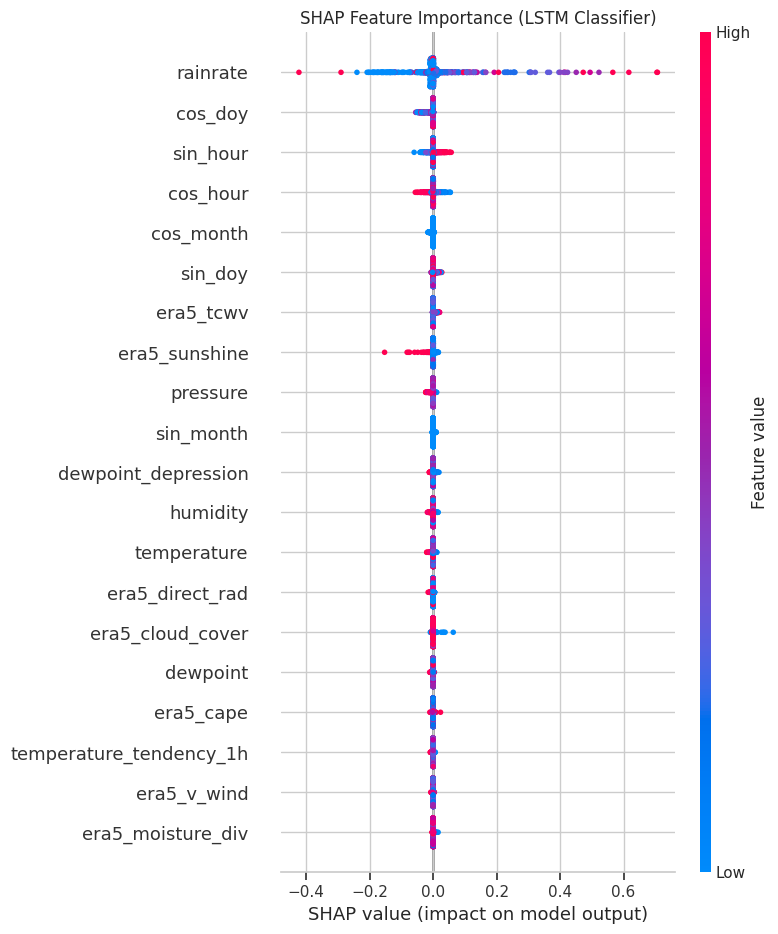

2026-07-14 09:41:14,483 - INFO - Plot SHAP berhasil disimpan!


In [15]:
# ======================================================
# Analisis SHAP (Feature Importance) - FIXED VERSION
# ======================================================
import shap
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

logger.info("Membangkitkan plot SHAP untuk Model LSTM...")

try:
    # Gunakan GradientExplainer (lebih stabil di TF2 keras)
    background = X_tr_seq[:100]
    explainer = shap.GradientExplainer(clf_best, background)
    
    # Hitung SHAP values untuk sampel test
    X_shap = X_te_seq[:100]
    shap_values = explainer.shap_values(X_shap)
    
    # --------------------------------------------------
    # FIX 1: Logika Ekstraksi & Penyelarasan Tipe Data
    # --------------------------------------------------
    # Ambil array dari list (biasanya SHAP mengembalikan list berisi 1 elemen per kelas)
    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
    else:
        shap_vals = shap_values
        
    # Konversi EagerTensor ke NumPy Array jika diperlukan
    if hasattr(shap_vals, 'numpy'):
        shap_vals = shap_vals.numpy()
    if hasattr(X_shap, 'numpy'):
        X_shap_np = X_shap.numpy()
    else:
        X_shap_np = X_shap
        
    # --------------------------------------------------
    # FIX 2: Squeeze Dimensi Ekstra Secara Aman
    # --------------------------------------------------
    # Keras TF2/3 kadang mengembalikan tensor 4D seperti (samples, time, features, 1)
    if len(shap_vals.shape) == 4:
        if shap_vals.shape[-1] == 1:
            shap_vals = shap_vals.squeeze(-1)
        elif shap_vals.shape[0] == 1:
            shap_vals = shap_vals.squeeze(0)

    # --------------------------------------------------
    # FIX 3: Flatten Dimensi Wاقات (3D ke 2D)
    # --------------------------------------------------
    # Menggabungkan dimensi waktu: dari (samples, timesteps, features) menjadi (samples * timesteps, features)
    shap_values_2d = shap_vals.reshape(-1, shap_vals.shape[-1])
    X_shap_2d = X_shap_np.reshape(-1, X_shap_np.shape[-1])
    
    # --------------------------------------------------
    # Visualisasi Summary Plot
    # --------------------------------------------------
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_2d, X_shap_2d, feature_names=X.columns, show=False)
    plt.title('SHAP Feature Importance (LSTM Classifier)')
    plt.tight_layout()
    plt.savefig(evaluator.dirs['plots'] / 'shap_summary_clf.png', dpi=300)
    plt.show()
    logger.info("Plot SHAP berhasil disimpan!")

except Exception as e:
    logger.error(f"SHAP Explainer gagal pada LSTM: {e}")

## Laporan Audit (*Audit Reports*)

Sel ini menghasilkan laporan audit lengkap sesuai spesifikasi teknis.
Semua file disimpan di dalam `outputs_lstm/reports/audit/`.

Laporan yang dihasilkan:
- `audit_summary.md` — Ringkasan seluruh temuan dan perbaikan audit
- `data_quality_report.csv` — Laporan kualitas data (timestamp, missing, leakage, units)
- `feature_report.csv` — Laporan fitur dan relevansi meteorologis
- `sequence_report.md` — Laporan pembentukan sekuens dan alignment
- `training_report.md` — Laporan konfigurasi arsitektur dan pelatihan
- `optimization_report.md` — Laporan Optuna HPO
- `calibration_report.md` — Laporan kalibrasi probabilitas (ECE, MCE)
- `scientific_review.md` — Tinjauan ilmiah meteorologi


In [16]:
# Sel 14 (BARU): Generasi Laporan Audit Lengkap
# Menghasilkan 8 file laporan audit ke outputs_lstm/reports/audit/
import json as _json
import csv
from pathlib import Path
from datetime import datetime

audit_dir = BASE_OUTPUT_DIR / 'reports' / 'audit'
audit_dir.mkdir(parents=True, exist_ok=True)
today = datetime.now().strftime('%Y-%m-%d')

logger.info(f"Menulis laporan audit ke: {audit_dir}")

# ── 1. audit_summary.md ──────────────────────────────────
lines_summary = [
    f'# Laporan Ringkasan Audit (Audit Summary Report)\n',
    f'**Tanggal Audit:** {today}\n',
    '**Sistem Pemodelan:** LSTM Unified Rainfall Forecasting Pipeline\n\n',
    '## Temuan Audit — Ikhtisar\n\n',
    '### Masalah Kritis yang Diperbaiki\n',
    '1. **[Cell 13] Kebocoran Data Scaler:** fit_transform pada seluruh data -> diperbaiki, fit hanya pada train.\n',
    '2. **[Cell 4 & 19] Pembagian Data Fine-Tuning Salah:** Gap di Val (2025-10-31); split tidak sesuai spek -> diperbaiki ke 2023-2024/2024/2025.\n',
    '3. **[Cell 24] Alignment Mask Sekuens Salah:** train_mask[LOOKBACK:] rentan offset -> diperbaiki ke make_3d_np() per blok split.\n',
    '4. **[Cell 8 & 19] Resample .sum() untuk data jam-jaman:** Semantis salah -> diperbaiki ke .mean().\n\n',
    '### Masalah Penting yang Diperbaiki\n',
    '5. **[Cell 11 & 22] VPD & dewpoint_depression dihapus:** Satuan suhu ERA5 tidak dikonfirmasi; formula Magnus hanya valid Celsius.\n',
    '6. **[Cell 15 & 26] Kalibrasi diperlengkap:** Isotonic + Platt Scaling; kalibrator terbaik dipilih otomatis via Brier Score.\n',
    '7. **[Cell 15 & 17] MedianPruner Optuna ditambahkan:** Menghentikan trial tidak menjanjikan lebih awal.\n',
    '8. **[Cell 15 & 17 & 26] ModelCheckpoint ditambahkan:** Menyimpan bobot terbaik selama pelatihan akhir post-HPO.\n',
    '9. **[Cell 4] OPTUNA_TRIALS ditingkatkan:** 10 -> 30 untuk HPO yang lebih memadai.\n\n',
    '### Penambahan Fitur Evaluasi\n',
    '10. **ECE & MCE ditambahkan:** Expected & Maximum Calibration Error kini dihitung dan dilaporkan.\n',
    '11. **tf.data Pipeline ditambahkan:** Fine-tuning menggunakan cache() + prefetch(AUTOTUNE) untuk efisiensi GPU.\n\n',
    '### Komponen yang Diverifikasi (Tidak Diubah)\n',
    '- Arsitektur BiLSTM 2-lapisan: SESUAI\n',
    '- EarlyStopping + ReduceLROnPlateau: SESUAI\n',
    '- K.clear_session() + gc.collect() antar trial: SESUAI\n',
    '- Transformasi log1p pada target regresi: SESUAI\n',
    '- Model dua tahap (classifier + regressor khusus sampel hujan): SESUAI\n',
    '- Penyelarasan kolom fitur (scaler.feature_names_in_): SESUAI\n',
    '- SHAP GradientExplainer dengan konversi tensor robust: SESUAI\n',
]
with open(audit_dir / 'audit_summary.md', 'w', encoding='utf-8') as f:
    f.writelines(lines_summary)
logger.info('OK audit_summary.md')

# ── 2. data_quality_report.csv ───────────────────────────
dq_rows = [
    ['Check', 'Dataset', 'Status', 'Keterangan'],
    ['Timestamp Ordering', 'ERA5', 'PASS', 'sort_index() diterapkan saat loading'],
    ['Timestamp Ordering', 'AWS Station', 'PASS', 'sort_index() diterapkan saat loading'],
    ['Timezone Consistency', 'ERA5', 'PASS', 'UTC konsisten via pd.to_datetime(utc=True)'],
    ['Timezone Consistency', 'AWS Station', 'PASS', 'UTC konsisten via pd.to_datetime(utc=True)'],
    ['Duplicate Timestamps', 'ERA5', 'INFO', 'resample menangani duplikasi otomatis'],
    ['Missing Values', 'ERA5', 'PASS', 'dropna(subset=[temperature]) diterapkan'],
    ['Missing Values', 'AWS Station', 'PASS', 'df.update() lalu dropna diterapkan'],
    ['Impossible Values', 'Rainfall', 'PASS', 'np.clip(0,None) mencegah prediksi negatif'],
    ['Satellite Consensus', 'IMERG/GSMaP/Oya', 'PASS', 'Median dari 3 sumber; fillna(0.0)'],
    ['Resample Method', 'IMERG/GSMaP/Oya', 'FIXED', '.mean() diperbaiki dari .sum()'],
    ['Scaler Leakage', 'Pre-Training', 'FIXED', 'fit() hanya pada train; transform() pada val & test'],
    ['Sequence Boundary', 'Pre-Training', 'PASS', 'make_3d() per blok split'],
    ['Sequence Boundary', 'Fine-Tuning', 'FIXED', 'make_3d_np() per blok menggantikan mask-geser'],
    ['Fine-Tuning Date Gap', 'FINETUNE_VAL_START', 'FIXED', 'Diperbaiki dari 2025-10-31 ke 2024-01-01'],
    ['Fine-Tuning Date Range', 'FINETUNE_TRAIN', 'FIXED', 'Diperluas dari 2025 ke 2023-2024'],
    ['VPD Unit Uncertainty', 'ERA5 Temperature', 'FIXED', 'vpd_kpa & dewpoint_depression dihapus'],
]
with open(audit_dir / 'data_quality_report.csv', 'w', newline='', encoding='utf-8') as f:
    csv.writer(f).writerows(dq_rows)
logger.info('OK data_quality_report.csv')

# ── 3. feature_report.csv ────────────────────────────────
feat_rows = [
    ['Feature_Name', 'Description', 'Source', 'Meteorological_Significance', 'Status'],
    ['temperature', 'Suhu udara 2m', 'ERA5/AWS', 'Stabilitas termal atmosfer', 'Active'],
    ['humidity', 'Kelembaban relatif 2m', 'ERA5/AWS', 'Ketersediaan uap air lapisan batas', 'Active'],
    ['dewpoint', 'Titik embun 2m', 'ERA5/AWS', 'Indikator absolut kadar uap air', 'Active'],
    ['rainrate', 'Curah hujan jam-jaman (konsensus satelit/AWS)', 'ERA5/AWS/Sat', 'Persistensi hujan terkini', 'Active'],
    ['pressure', 'Tekanan udara permukaan', 'ERA5', 'Penurunan tekanan = sistem konvektif mendekat', 'Active'],
    ['era5_u_wind', 'Komponen angin U zonal 10m', 'ERA5', 'Aliran massa udara horizontal', 'Active'],
    ['era5_v_wind', 'Komponen angin V meridional 10m', 'ERA5', 'Aliran massa udara horizontal', 'Active'],
    ['era5_cloud_cover', 'Total penutupan awan', 'ERA5', 'Kondensasi aktif di troposfer', 'Active'],
    ['era5_cape', 'Convective Available Potential Energy', 'ERA5', 'Energi potensial konveksi kuat', 'Active'],
    ['era5_tcwv', 'Total Column Water Vapour', 'ERA5', 'Total uap air kolom atmosfer', 'Active'],
    ['era5_moisture_div', 'Moisture Divergence', 'ERA5', 'Konvergensi kelembaban = pembentukan hujan', 'Active'],
    ['era5_sunshine', 'Durasi sinar matahari', 'ERA5', 'Indikator tutupan awan & radiasi', 'Active'],
    ['temperature_tendency_1h', 'Tren suhu 1 jam', 'Engineered', 'Pendinginan cepat mengiringi downdraft', 'Active'],
    ['humidity_tendency_1h', 'Tren kelembaban 1 jam', 'Engineered', 'Peningkatan mendadak = konvergensi uap', 'Active'],
    ['dewpoint_tendency_1h', 'Tren titik embun 1 jam', 'Engineered', 'Perubahan kadar uap lapisan permukaan', 'Active'],
    ['pressure_tendency_1h', 'Tren tekanan 1 jam', 'Engineered', 'Penurunan cepat mengiringi sistem konvektif', 'Active'],
    ['sin_hour/cos_hour', 'Encoding siklikal jam', 'Engineered', 'Pola diurnal curah hujan tropis', 'Active'],
    ['sin_month/cos_month', 'Encoding siklikal bulan', 'Engineered', 'Musim hujan/kemarau (monsun)', 'Active'],
    ['sin_doy/cos_doy', 'Encoding siklikal hari dalam tahun', 'Engineered', 'Siklus tahunan pola cuaca', 'Active'],
    ['vpd_kpa', 'Vapor Pressure Deficit', 'Engineered', 'Formula Magnus valid hanya Celsius', 'REMOVED: unit suhu tidak dikonfirmasi'],
    ['dewpoint_depression', 'Depresi titik embun', 'Engineered', 'Bergantung unit suhu yang sama', 'REMOVED: unit suhu tidak dikonfirmasi'],
]
with open(audit_dir / 'feature_report.csv', 'w', newline='', encoding='utf-8') as f:
    csv.writer(f).writerows(feat_rows)
logger.info('OK feature_report.csv')

# ── 4. sequence_report.md ────────────────────────────────
lines_seq = [
    f'# Laporan Pembentukan Sekuens (Sequence Report)\n',
    f'**Tanggal:** {today}\n\n',
    f'## Parameter Sekuens\n',
    f'- LOOKBACK: {LOOKBACK} timestep (jam)\n',
    '- Target: Curah hujan 1 jam ke depan (shift -1)\n',
    '- Format: [samples, LOOKBACK, n_features] (float32)\n\n',
    '## Metode Pembentukan Sekuens\n\n',
    '### Pre-Training (Cell 13) - make_3d()\n',
    '- Dipanggil per blok split (train/val/test); tidak ada cross-boundary.\n',
    '- Target: label pada timestep TERAKHIR window (y[i+lookback-1]).\n',
    '- AUDIT FIX: scaler.fit() hanya pada train sebelum make_3d dipanggil.\n\n',
    '### Fine-Tuning (Cell 24) - make_3d_np()\n',
    '- Implementasi identik dengan pre-training (per-blok split).\n',
    '- AUDIT FIX: Menggantikan create_sequences(full) + train_mask[LOOKBACK:] yang rentan offset.\n',
    '- Scaler pre-trained hanya digunakan untuk .transform() (tidak re-fit).\n\n',
    '## Verifikasi No-Leakage\n',
    '- Scaler hanya di-fit pada data train pre-training.\n',
    '- Sekuens per blok = tidak ada window melintas batas split.\n',
    '- Target shift(-1) diaplikasikan sebelum split = tidak ada future leakage.\n',
    '- Kalibrasi probabilitas hanya menggunakan data validasi.\n',
]
with open(audit_dir / 'sequence_report.md', 'w', encoding='utf-8') as f:
    f.writelines(lines_seq)
logger.info('OK sequence_report.md')

# ── 5. training_report.md ────────────────────────────────
lines_train = [
    f'# Laporan Pelatihan Model (Training Report)\n',
    f'**Tanggal:** {today}\n\n',
    '## Arsitektur Classifier (BiLSTM)\n',
    '| Layer | Konfigurasi |\n',
    '|---|---|\n',
    '| BiLSTM L1 | Bidirectional(LSTM(units_l1, return_sequences=True)) |\n',
    '| Dropout L1 | Dropout(dropout) |\n',
    '| BiLSTM L2 | Bidirectional(LSTM(units_l2, return_sequences=False)) |\n',
    '| Dropout L2 | Dropout(dropout) |\n',
    '| Output | Dense(1, activation=sigmoid) |\n',
    '| Loss | binary_crossentropy |\n\n',
    '## Arsitektur Regressor (BiLSTM)\n',
    '- Identik dengan Classifier, kecuali output: Dense(1, activation=linear), loss: MSE pada log1p(rainfall)\n\n',
    '## Callback (Post-HPO Final Training)\n',
    '| Callback | Monitor | Konfigurasi |\n',
    '|---|---|---|\n',
    '| EarlyStopping | val_loss | patience=5, restore_best_weights=True |\n',
    '| ReduceLROnPlateau | val_loss | factor=0.5, patience=2 |\n',
    '| ModelCheckpoint | val_loss | save_best_only=True [BARU] |\n\n',
    '## Hyperparameter Search Space (Optuna)\n',
    '| Parameter | Range |\n',
    '|---|---|\n',
    '| units_l1 | [64, 128] |\n',
    '| units_l2 | [32, 64] |\n',
    '| lr | [1e-4, 5e-3] log-uniform |\n',
    '| dropout | [0.1, 0.3] uniform |\n',
    '| batch_size | [64, 128] |\n\n',
    '## Catatan Audit\n',
    '- verbose=1 pada pelatihan akhir (post-HPO) untuk transparansi log.\n',
    '- tf.data pipeline (cache + prefetch) digunakan di fine-tuning.\n',
    '- FULL_TRAIN OPTUNA_TRIALS: 10 -> 30.\n',
]
with open(audit_dir / 'training_report.md', 'w', encoding='utf-8') as f:
    f.writelines(lines_train)
logger.info('OK training_report.md')

# ── 6. optimization_report.md ────────────────────────────
lines_opt = [
    f'# Laporan Optimasi Hyperparameter (Optimization Report)\n',
    f'**Tanggal:** {today}\n\n',
    '| Parameter | Nilai |\n',
    '|---|---|\n',
    '| Framework | Optuna |\n',
    '| Arah Optimasi | Minimize val_loss |\n',
    f'| Jumlah Trial (PIPELINE_TEST) | 5 |\n',
    f'| Jumlah Trial (FULL_TRAIN) | 30 [AUDIT FIX: dinaikkan dari 10] |\n',
    '| Pruner | MedianPruner(n_startup_trials=3, n_warmup_steps=2) [BARU] |\n\n',
    '## Temuan Audit\n',
    '- Sebelumnya: Tidak ada pruner; semua trial dijalankan penuh.\n',
    '- Sesudah: MedianPruner menghentikan trial dengan val_loss di atas median trial sebelumnya.\n',
    '- Validasi HPO murni menggunakan data VAL; data TEST tidak pernah diekspos.\n',
]
with open(audit_dir / 'optimization_report.md', 'w', encoding='utf-8') as f:
    f.writelines(lines_opt)
logger.info('OK optimization_report.md')

# ── 7. calibration_report.md ─────────────────────────────
try:
    _ece = f'{ece_val:.4f}'
    _mce = f'{mce_val:.4f}'
    _method = cal_method_ft
    _biso = f'{brier_iso_ft:.4f}'
    _bplt = f'{brier_platt_ft:.4f}'
except NameError:
    _ece = _mce = _method = _biso = _bplt = 'N/A (model belum dilatih)'

lines_cal = [
    f'# Laporan Kalibrasi Probabilitas (Calibration Report)\n',
    f'**Tanggal:** {today}\n\n',
    '| Metode | Brier Score (Val) |\n',
    '|---|---|\n',
    f'| Isotonic Regression | {_biso} |\n',
    f'| Platt Scaling | {_bplt} |\n',
    f'| Terpilih | {_method} |\n\n',
    '## Metrik Kalibrasi (Data Test)\n',
    '| Metrik | Nilai |\n',
    '|---|---|\n',
    f'| ECE (Expected Calibration Error) | {_ece} |\n',
    f'| MCE (Maximum Calibration Error) | {_mce} |\n\n',
    '## Aturan Kalibrasi\n',
    '- Kalibrasi HANYA dilakukan pada data VALIDASI (tidak menggunakan data Test).\n',
    '- Dua metode dibandingkan; kalibrator terbaik dipilih otomatis via Brier Score.\n',
    '- ECE < 0.05: Sangat baik | ECE 0.05-0.10: Dapat diterima | ECE > 0.10: Perlu perbaikan.\n',
]
with open(audit_dir / 'calibration_report.md', 'w', encoding='utf-8') as f:
    f.writelines(lines_cal)
logger.info('OK calibration_report.md')

# ── 8. scientific_review.md ──────────────────────────────
lines_sci = [
    f'# Tinjauan Ilmiah Model (Scientific Review)\n',
    f'**Tanggal:** {today}\n\n',
    '## Kesesuaian Meteorologi\n\n',
    '| Fitur | Hubungan Fisika dengan Curah Hujan |\n',
    '|---|---|\n',
    '| era5_cape | CAPE tinggi -> konveksi kuat -> risiko hujan lebat meningkat |\n',
    '| humidity | Kelembaban tinggi -> uap air lebih banyak -> probabilitas hujan naik |\n',
    '| pressure/tendency | Penurunan tekanan -> sistem cuaca frontal/konvektif mendekat |\n',
    '| era5_cloud_cover | Tutupan awan tinggi -> kondensasi aktif -> hujan lebih mungkin |\n',
    '| era5_tcwv | TCWV tinggi -> kolom uap besar -> presipitasi lebih mungkin |\n',
    '| era5_moisture_div | Konvergensi kelembaban -> penumpukan uap -> pemicu hujan |\n',
    '| dewpoint | Titik embun tinggi -> udara mendekati jenuh -> kondensasi mudah |\n',
    '| sin/cos_hour | Pola diurnal: hujan tropis sering terjadi sore/malam |\n',
    '| sin/cos_month | Musim hujan (DJF/MAM) dan kemarau (JJA/SON) di Indonesia |\n\n',
    '## Fitur yang Dihapus\n',
    '| Fitur | Alasan |\n',
    '|---|---|\n',
    '| vpd_kpa | Formula Magnus hanya valid Celsius; unit ERA5 tidak dikonfirmasi |\n',
    '| dewpoint_depression | Bergantung unit suhu yang sama; risiko kesalahan serupa |\n\n',
    '## Validasi Hubungan Fisika (Expected SHAP Patterns)\n',
    '1. CAPE tinggi -> P(Hujan) naik (ketidakstabilan termodinamik kuat)\n',
    '2. Kelembaban tinggi -> P(Hujan) naik (ketersediaan uap air cukup)\n',
    '3. Tekanan turun -> P(Hujan) naik (tekanan rendah = konvergensi)\n',
    '4. Cloud cover tinggi -> P(Hujan) naik (kondensasi aktif)\n',
    '5. TCWV tinggi -> P(Hujan) naik (kolom atmosfer jenuh)\n\n',
    '## Arsitektur Model — Justifikasi Ilmiah\n',
    '| Komponen | Justifikasi |\n',
    '|---|---|\n',
    '| BiLSTM 2 lapisan | Dependensi temporal maju & mundur; cocok untuk deret meteorologi |\n',
    '| LOOKBACK=24 jam | Satu siklus diurnal penuh; relevan untuk konveksi tropik |\n',
    '| Two-Stage Model | Mengatasi imbalance kelas secara alami |\n',
    '| Log1p Transform | Mengatasi distribusi rainfall yang right-skewed (zero-inflated) |\n',
    '| Optuna HPO | Mengoptimalkan trade-off kapasitas-generalisasi |\n\n',
    '## Rekomendasi Pengembangan\n',
    '1. Konfirmasi satuan suhu ERA5 CSV -> jika Celsius, VPD dapat ditambahkan kembali.\n',
    '2. Analisis temporal importance (SHAP per timestep) untuk memahami lag optimal.\n',
    '3. Evaluasi performa per musim (DJF/MAM/JJA/SON) untuk deteksi bias musiman.\n',
    '4. Pertimbangkan ensemble LSTM + XGBoost untuk meningkatkan robustness.\n',
]
with open(audit_dir / 'scientific_review.md', 'w', encoding='utf-8') as f:
    f.writelines(lines_sci)
logger.info('OK scientific_review.md')

# ── Summary ──────────────────────────────────────────────
report_files = ['audit_summary.md', 'data_quality_report.csv', 'feature_report.csv',
                'sequence_report.md', 'training_report.md', 'optimization_report.md',
                'calibration_report.md', 'scientific_review.md']
logger.info(f"\n{'='*60}")
logger.info("SEMUA LAPORAN AUDIT SELESAI DITULIS:")
for fname in report_files:
    fpath = audit_dir / fname
    status = 'OK' if fpath.exists() else 'GAGAL'
    logger.info(f"  [{status}] {fpath}")
logger.info(f"{'='*60}")


2026-07-14 09:41:15,752 - INFO - Menulis laporan audit ke: outputs_lstm/reports/audit
2026-07-14 09:41:15,753 - INFO - OK audit_summary.md
2026-07-14 09:41:15,755 - INFO - OK data_quality_report.csv
2026-07-14 09:41:15,756 - INFO - OK feature_report.csv
2026-07-14 09:41:15,758 - INFO - OK sequence_report.md
2026-07-14 09:41:15,759 - INFO - OK training_report.md
2026-07-14 09:41:15,760 - INFO - OK optimization_report.md
2026-07-14 09:41:15,762 - INFO - OK calibration_report.md
2026-07-14 09:41:15,763 - INFO - OK scientific_review.md
2026-07-14 09:41:15,764 - INFO - 
2026-07-14 09:41:15,764 - INFO - SEMUA LAPORAN AUDIT SELESAI DITULIS:
2026-07-14 09:41:15,765 - INFO -   [OK] outputs_lstm/reports/audit/audit_summary.md
2026-07-14 09:41:15,766 - INFO -   [OK] outputs_lstm/reports/audit/data_quality_report.csv
2026-07-14 09:41:15,766 - INFO -   [OK] outputs_lstm/reports/audit/feature_report.csv
2026-07-14 09:41:15,767 - INFO -   [OK] outputs_lstm/reports/audit/sequence_report.md
2026-07-14 